# Import and Function Definition

In [1]:
%load_ext autoreload
%autoreload 2


import numpy as np
import matplotlib.pyplot as plt
import os, sys, pickle, glob
import qutip as qt
import textwrap
import experiments as meas

from copy import deepcopy
from collections import defaultdict
from tqdm.notebook import tqdm
from experiments.MM_dual_rail_base import MM_dual_rail_base
from fitting.fit_display_classes import GeneralFitting
from fitting.wigner import WignerAnalysis
from slab import AttrDict
from experiments import MultimodeStation, CharacterizationRunner, SweepRunner


REPO_ROOT = r"C:\python\multimode_expts" 
BASE_DIR  = r"C:\experiments"
RUN_PREFIX = "JOB-20260414"  

Importing all classes from  C:\Users\keoha\OneDrive\문서\GitHub\multimode_expts\experiments\calibration
Importing all classes from  C:\Users\keoha\OneDrive\문서\GitHub\multimode_expts\experiments\dual_rail
Importing all classes from  C:\Users\keoha\OneDrive\문서\GitHub\multimode_expts\experiments\qsim
Importing all classes from  C:\Users\keoha\OneDrive\문서\GitHub\multimode_expts\experiments\qubit_cavity
Importing all classes from  C:\Users\keoha\OneDrive\문서\GitHub\multimode_expts\experiments\single_qubit
Importing all classes from  C:\Users\keoha\OneDrive\문서\GitHub\multimode_expts\experiments\transduction
Skipped top-level files ['branch_manager.py', 'characterization_runner.py', 'dataset.py', 'MM_base.py', 'MM_dual_rail_base.py', 'MM_rb_base.py', 'mock_hardware.py', 'sequential_experiment.py', 'sequential_experiment_classes.py', 'station.py', 'sweep_runner.py']


# Helper Functions & Definitions

Run this section once (after the import cell). All later sections only call these -- no section depends on another.

In [2]:
# =====================================================================
# Helper Functions & Definitions -- run this ONE cell before any section
# below. Every function/class the notebook uses is defined here, so no
# section depends on another section's cells having been run first.
# (Requires the import cell above to have run: np, plt, meas, AttrDict, ...)
# =====================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import os, textwrap
from pathlib import Path
from collections import namedtuple, defaultdict



def pickle_return(filepath):
    with open(filepath, 'rb') as f:
        return pickle.load(f)

def experiment_list_return(experiment_name,
                           job_date,
                           job_start_num,
                           job_finish_num,
                           basedir = BASE_DIR,
                           verbose = False):
    object_directory = os.path.join(basedir, experiment_name, "expt_objs")
    exp_list_to_return = []
    job_path = f"JOB-{job_date}"
    for job_num in range(job_start_num, job_finish_num + 1):
        filepath = os.path.join(object_directory, f"{job_path}-{job_num:05d}_expt.pkl")
        try:
            exp_list_to_return.append(pickle_return(filepath))
        except Exception as e:
            if verbose == True:
                print(f"Error loading {filepath}: {e}")
            continue
    return exp_list_to_return

def retrieve_from_multiple_jobs(experiment_nane,
                                job_date_list,
                                job_start_num_list,
                                job_finish_num_list,
                                basedir = BASE_DIR):
    all_exp_list = []
    for job_date, job_start_num, job_finish_num in zip(job_date_list,job_start_num_list,job_finish_num_list):
        exp_list = experiment_list_return(experiment_nane,
                                          job_date,
                                          job_start_num,
                                          job_finish_num,
                                          basedir)
        all_exp_list.extend(exp_list)
    return all_exp_list

def check_program_class(obj,
                        class_name):
    if obj.prog.__class__.__name__ == class_name:
        return True
    return False

def job_id_generator(job_date, job_start_num, job_finish_num, step=1):
    starts = [job_start_num] if isinstance(job_start_num, (int, np.integer)) else list(job_start_num)
    finishes = [job_finish_num] if isinstance(job_finish_num, (int, np.integer)) else list(job_finish_num)
    dates = [job_date] * len(starts) if isinstance(job_date, (str, int, np.integer)) else list(job_date)
    steps = [step] * len(starts) if isinstance(step, (int, np.integer)) else list(step)
    if not (len(dates) == len(starts) == len(finishes) == len(steps)): raise ValueError('job range arguments must have matching lengths')
    return [f'JOB-{date}-{job:05d}' for date, start, finish, stride in zip(dates, starts, finishes, steps) for job in range(int(start), int(finish) + 1, int(stride))]

def hdf5_path_generator(project_name,
                        job_date,
                        job_start_num,
                        job_finish_num, 
                        experiement_name,
                        basedir = BASE_DIR,
                        verbose = False):
    object_directory = os.path.join(basedir, project_name, "data")
    path = {}
    hdf5_path_to_return = []
    for job_id in job_id_generator(job_date, job_start_num, job_finish_num):
        filepath = os.path.join(object_directory, f"{job_id}_{experiement_name}.h5")
        if os.path.exists(filepath):
            hdf5_path_to_return.append(filepath)
            if verbose: print(f"[O] Found: {filepath}")
        elif verbose: print(f"[X] Missing: {filepath}")
    path[experiement_name] = hdf5_path_to_return
    return path

def path_to_experiment(hdf5_path, ExpClass):
    
    exp_name = list(hdf5_path.keys())[0]
    path_list = hdf5_path[exp_name]

    exp_list = []

    for fname in tqdm(path_list):
        obj = ExpClass.from_h5file(fname)

        obj.path = os.path.dirname(fname)
        obj.config_file = fname
        obj.prefix = os.path.splitext(os.path.basename(fname))[0]

        exp_list.append(obj)

    return exp_list

def _legacy_floquet_cycle_us(self, swap_stors=None):
    # Use the cycle calculation from the August acquisition code.
    ecfg = self.cfg.expt
    if swap_stors is None:
        swap_stors = ecfg.swap_stors
    cycle_us = len(swap_stors) * self.cycles2us(ecfg.get("scramble_sync_cycles", 10))
    for stor in swap_stors:
        index = stor - 1
        ch = self.m1s_ch[index]
        if self.m1s_style[index] == "arb":
            sigma_us = ecfg.get("floquet_gauss_sigma", None)
            if sigma_us is None:
                sigma_us = self.swap_ds.get_gauss_sigma(f"M1-S{stor}")
            pulse_cycles = self.us2cycles(sigma_us, gen_ch=ch) * self.swap_ds.get_gauss_n_sigma(f"M1-S{stor}")
        else:
            ramp_cycles = self.pi_m1_sigma_low if self.m1s_is_low_freq[index] else self.pi_m1_sigma_high
            pulse_cycles = self.m1s_length[index] + 6 * ramp_cycles
        cycle_us += self.cycles2us(pulse_cycles, gen_ch=ch)
    return cycle_us


def _restore_legacy_waveform_modes(expts):
    from types import MethodType
    labels = {'arb': 'gauss', 'flat_top': 'flat_top'}
    for expt in expts:
        prog = getattr(expt, 'prog', None)
        if prog is not None and not hasattr(prog, 'm1s_waveform_mode'):
            prog.m1s_waveform_mode = [labels[style] for style in prog.m1s_style]
            prog.calculate_floquet_cycle_us = MethodType(_legacy_floquet_cycle_us, prog)


def load_encoding_job_ids_legacy(EncSpec, *args, **kwargs):
    expt = EncSpec.from_job_ids(*args, **kwargs)
    _restore_legacy_waveform_modes(expt.batch_expts)
    return expt


def load_encoding_spectroscopy_legacy(EncSpec, calibration_job_ids, spectroscopy_job_ids, client=None, calibration_program_name='EntireFloquetCyclePhaseCalibrationProgram', spectroscopy_program_name='NPhotonHamiltonianSpectroscopyProgram'):
    if client is None:
        from job_server import JobClient
        client = JobClient()
    def load_selected(job_ids, selector):
        expts, loaded_job_ids, skipped_job_ids = [], [], []
        for job_id in job_ids:
            try:
                result = client.get_status(job_id)
                if not result.is_successful():
                    skipped_job_ids.append(job_id)
                    continue
                expt = result.load_expt()
                keep = selector(expt)
            except Exception:
                skipped_job_ids.append(job_id)
                continue
            if keep:
                expts.append(expt)
                loaded_job_ids.append(job_id)
            else:
                skipped_job_ids.append(job_id)
        return expts, loaded_job_ids, skipped_job_ids
    calibration_expts, calibration_loaded_job_ids, calibration_skipped_job_ids = load_selected(calibration_job_ids, lambda expt: check_program_class(expt, calibration_program_name))
    spectroscopy_expts, spectroscopy_loaded_job_ids, spectroscopy_skipped_job_ids = load_selected(spectroscopy_job_ids, lambda expt: isinstance(expt, EncSpec) or check_program_class(expt, spectroscopy_program_name))
    _restore_legacy_waveform_modes(calibration_expts + spectroscopy_expts)
    calibration_expt = EncSpec._from_expts(calibration_expts, job_ids=calibration_loaded_job_ids)
    spectroscopy_expt = EncSpec._from_expts(spectroscopy_expts, job_ids=spectroscopy_loaded_job_ids)
    calibration_expt.skipped_job_ids = calibration_skipped_job_ids
    spectroscopy_expt.skipped_job_ids = spectroscopy_skipped_job_ids
    calibration_expt.analyze(stage='calibration')
    return calibration_expt, spectroscopy_expt

load_encoding_spectroscopy = load_encoding_spectroscopy_legacy

def get_inlier_indices(x, y, threshold=2.0):
    valid = np.isfinite(x) & np.isfinite(y)
    current_valid = valid.copy()
    indices = np.arange(len(x))
    
    for _ in range(10):  
        x_fit = x[current_valid]
        y_fit = y[current_valid]
        
        if len(x_fit) < 2:
            break 
            
        p = np.polyfit(x_fit, y_fit, 1)
        y_pred = np.polyval(p, x)
        
        residuals = np.abs(y - y_pred)
        
        mad = np.median(residuals[current_valid])
        sigma = 1.4826 * mad
        
        if sigma < 1e-10:  
            break
            
        new_valid = valid & (residuals < threshold * sigma)
        
        if np.array_equal(new_valid, current_valid):
            break 
            
        current_valid = new_valid
        
    return np.where(current_valid)[0]

def plot_freq_line_cut(target_freq):
    plot_gains = []
    plot_kerrs = []
    
    for expt in excursion_list:
        is_good = not getattr(expt, 'is_bad_data', False)
        is_target = (expt.cfg.expt.get('kerr_freq', np.nan) == target_freq)
        
        
        if is_target and is_good:
            plot_gains.append(expt.cfg.expt['kerr_gain'])
            plot_kerrs.append(np.abs(expt.data['Kerr'])) 
            
    if not plot_gains:
        print(f"No valid data for kerr freq = {target_freq}")
        return
        
    plt.figure(figsize=(8, 5))
    plt.scatter(plot_gains, plot_kerrs, s=50, label=f'Freq = {target_freq}')
    
    plt.xlabel('Gain [a.u.]', fontsize=12)
    plt.ylabel('|Kerr|', fontsize=12)
    plt.title(f'Kerr vs Gain Line Cut (Freq: {target_freq})', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

def estimate_periodicity(y, sampling_rate=1.0):
        # Compute FFT
        fft = np.fft.fft(y - np.mean(y))  # remove DC offset
        freqs = np.fft.fftfreq(len(y), d=1/sampling_rate)

        # Only take the positive frequencies
        pos_mask = freqs > 0
        freqs = freqs[pos_mask]
        power = np.abs(fft[pos_mask])

        # Find the dominant frequency
        dominant_freq = freqs[np.argmax(power)]

        # Convert frequency to period
        estimated_period = 1 / dominant_freq if dominant_freq != 0 else np.inf
        return estimated_period

def fit_model(x, alpha2, f, scale, offset, phase):
    return scale * np.exp(-2.0*alpha2*(1.0 + np.cos(2.0*np.pi*f*x - phase))) + offset

def fit_func(x, kc, delta):
    return  kc * x + delta

def estimate_phase(y, debug = False):
    if debug == True:
        print("y[0]", y[0], "min", np.min(y), "max", np.max(y))
    return np.abs(y[0] - np.min(y)) / np.abs(np.max(y) - np.min(y)) * np.pi/2

def normalize(z, exp_obj):
    Ig = exp_obj.cfg.device.readout.Ig[0]
    Ie = exp_obj.cfg.device.readout.Ie[0]
    return (z - Ig) / (Ie - Ig)

def _cfg_get(cfg, path, default=None):
    cur = cfg
    for key in path.split("."):
        if cur is None:
            return default
        if isinstance(cur, dict):
            cur = cur.get(key, None)
        else:
            cur = getattr(cur, key, None)
    return default if cur is None else cur

def _normalize_from_obj_or_cfg(obj, avgi_2d):
    if hasattr(obj, "normalize") and callable(getattr(obj, "normalize")):
        try:
            return obj.normalize(avgi_2d)
        except Exception:
            pass

    Ig = _cfg_get(obj.cfg, "device.readout.Ig", None)
    Ie = _cfg_get(obj.cfg, "device.readout.Ie", None)
    if Ig is None or Ie is None:
        return np.array(avgi_2d, float)

    Ig = float(Ig[0] if isinstance(Ig, (list, tuple, np.ndarray)) else Ig)
    Ie = float(Ie[0] if isinstance(Ie, (list, tuple, np.ndarray)) else Ie)
    denom = (Ie - Ig)
    if denom == 0:
        return np.array(avgi_2d, float)
    return (np.array(avgi_2d, float) - Ig) / denom

def kerr_ramsey_model_phi(x, alpha2, f, phi0, scale, offset):
    return scale * np.exp(-2.0 * alpha2 * (1.0 + np.cos(2.0*np.pi*f*x + phi0))) + offset

def linear_model(x, kc, delta):
    return kc * x + delta

def post_refit_one_cavity_ramsey_v2(
    obj,
    *,
    smooth_sigma=1.5,
    rsq_threshold=0.2,
    f_window_mhz=5.0,       
    # alpha2_mode="bounded",     
    alpha2_bound_ratio=(0.3, 3.0),
    use_smoothed_for_fit=True,
    verbose=False,
    method_setting = None
):
    # x/y
    x = np.array(obj.data.get("xpts", _cfg_get(obj.cfg, "expt.kerr_lengths")), float)
    y = np.array(obj.data.get("gain_list", _cfg_get(obj.cfg, "expt.displace_gains")), float)

    avgi_2d = np.array(obj.data["g_avgi"], float)
    n_lines, n_x = avgi_2d.shape

    z = _normalize_from_obj_or_cfg(obj, avgi_2d)

    virtual_freq = float(_cfg_get(obj.cfg, "expt.ramsey_freq", 0.0) or 0.0)

    g2a = _cfg_get(obj.cfg, "device.manipulate.gain_to_alpha", None)
    man_mode_no = obj.cfg.expt.get('man_mode_no', 1)
    if isinstance(g2a, (list, tuple, np.ndarray)):
        g2a = g2a[man_mode_no-1] if len(g2a) else None

    model = Model(kerr_ramsey_model_phi)

    fit_lids, fit_results, z_fits, rsqs = [], [], [], []
    alpha2_fits, f_fits, phi0_fits = [], [], []

    for lid in range(n_lines):
        line = np.array(z[lid, :], float)
        line_sm = gaussian_filter1d(line, sigma=smooth_sigma)

        yfit = line_sm if use_smoothed_for_fit else line

        off0 = float(np.nanmin(yfit))
        sc0 = float(np.nanmax(yfit) - off0)
        sc0 = max(sc0, 1e-3)

        if g2a is not None:
            alpha_guess = float(y[lid]) * float(g2a)
            alpha2_0 = max(alpha_guess*alpha_guess, 0.0)
        else:
            alpha2_0 = 0.2  # fallback

        params = model.make_params(
            alpha2=alpha2_0,
            f=virtual_freq,
            phi0=0.0,
            scale=sc0,
            offset=off0,
        )

        # if alpha2_mode == "fixed":
        params["alpha2"].set(value=alpha2_0, vary=False)
        # elif alpha2_mode == "bounded":
        #     lo, hi = alpha2_bound_ratio
        #     params["alpha2"].set(value=alpha2_0,
        #                          min=max(lo*alpha2_0, 0.0),
        #                          max=max(hi*alpha2_0, 1e-12),
        #                          vary=True)
        # elif alpha2_mode == "free":
        #     params["alpha2"].set(value=alpha2_0, min=0.0, vary=True)
        # else:
        #     raise ValueError("alpha2_mode must be fixed|bounded|free")
        if f_window_mhz == None:
            params["f"].set(value=virtual_freq)
        else:
            params["f"].set(value=virtual_freq #)
                            , min=virtual_freq - f_window_mhz
                            , max=virtual_freq + f_window_mhz)

        params["phi0"].set(value=0.0, min=-np.pi, max=np.pi)

        params["scale"].set(value=sc0, min=0.0, max=2.0)
        params["offset"].set(value=off0)#, min=-0.5, max=1.5)

        try:
            # res = model.fit(yfit, params, x=x[lid], nan_policy="omit",
            if method_setting == "basinhopping" :
                res_global = model.fit(yfit, params, x=x[lid], nan_policy="omit", 
                                    method="basinhopping")
                res = model.fit(yfit, res_global.params, x=x[lid], nan_policy="omit", 
                                method="leastsq")
            else:
                res = model.fit(yfit, params, x=x[lid], nan_policy="omit", 
                                    method="leastsq")
            fit_lids.append(lid)
            fit_results.append(res)
            z_fits.append(res.best_fit)

            alpha2_fits.append(float(res.params["alpha2"].value))
            f_fits.append(float(res.params["f"].value))
            phi0_fits.append(float(res.params["phi0"].value))
            rsq = float(getattr(res, "rsquared", np.nan))
            rsqs.append(rsq)

            if verbose:
                print(f"lid={lid:3d} rsq={rsq:.3f} f={f_fits[-1]:.4f} phi0={phi0_fits[-1]:+.3f} alpha2={alpha2_fits[-1]:.3g}")

        except Exception as e:
            if verbose:
                print(f"lid={lid:3d} failed: {e!r}")
            continue

    fit_lids = np.array(fit_lids, int)
    rsqs = np.array(rsqs, float)
    alpha2_fits = np.array(alpha2_fits, float)
    f_fits = np.array(f_fits, float)
    phi0_fits = np.array(phi0_fits, float)
    z_fits = np.array(z_fits, float) if len(z_fits) else np.zeros((0, n_x), float)

    fit_good = np.isfinite(rsqs) & (rsqs > rsq_threshold)

    alpha2_good = alpha2_fits[fit_good]
    f_det = (f_fits[fit_good] - virtual_freq)

    # linear fit
    kc = np.nan
    delta = np.nan
    linear_fit_result = None
    try:
        if len(alpha2_good) >= 2:
            lm = Model(linear_model, independent_vars=["x"])
            lp = lm.make_params(kc=1.0, delta=0.0)
            linear_fit_result = lm.fit(f_det, lp, x=alpha2_good, nan_policy="omit")
            kc = float(linear_fit_result.params["kc"].value)
            delta = float(linear_fit_result.params["delta"].value)
    except Exception:
        pass

    obj.fit_results = AttrDict(dict(
        alpha2=alpha2_good,
        f=f_det,
        kc=kc,
        delta=delta,
        linear_fit_result=linear_fit_result,

        results=fit_results,
        z_fits=z_fits,
        rsquared=rsqs,
        fit_lids=fit_lids,
        fit_good=fit_good,

        virtual_freq=virtual_freq,
        f_window_mhz=f_window_mhz,
        # alpha2_mode=alpha2_mode,
    ))

    return obj.fit_results

def _first_scalar(value):
    arr = np.asarray(value)
    if arr.size == 0:
        return None
    out = arr.reshape(-1)[0]
    return out.item() if hasattr(out, 'item') else out

def wigner_stor_label(ro_stor):
    return 'M1' if int(ro_stor) == 0 else f'S{int(ro_stor)}'

def _ensure_multiparity_read_num(expt):
    """Backfill expt.cfg.read_num when it was not saved to the .h5 (e.g. Qsim
    runs). Defined here so this cell is self-contained -- do not rely on the copy
    in the confusion-matrix cell being run first."""
    if 'read_num' in expt.cfg:
        return

    reps = int(expt.cfg.expt.get('reps', 1))
    rounds = int(expt.cfg.expt.get('rounds', 1))
    shots_per_point = np.asarray(expt.data['idata'][0]).size
    shots_per_round = max(reps * rounds, 1)
    if shots_per_point % shots_per_round == 0:
        expt.cfg.read_num = shots_per_point // shots_per_round
        return

    read_num = 1
    if expt.cfg.expt.get('parity_check', False):
        read_num += 1
    if expt.cfg.expt.get('active_reset', False):
        try:
            from experiments.MM_base import MMAveragerProgram
            params = MMAveragerProgram.get_active_reset_params(expt.cfg)
            read_num += MMAveragerProgram.active_reset_read_num(**params)
        except Exception:
            pass
    if expt.cfg.expt.get('multiparity_readout', False):
        read_num += 1
    expt.cfg.read_num = read_num

def _nmod4_from_two_parity_readouts(expt, point_idx=0, threshold=None, e_is_high_I=True):
    _ensure_multiparity_read_num(expt)
    rn = int(expt.cfg.read_num)
    q_test = int(expt.cfg.expt.qubits[0])
    if threshold is None:
        threshold = expt.cfg.device.readout.threshold[q_test]

    idata = np.asarray(expt.data['idata'][point_idx])
    i_first = idata[rn - 2::rn]
    i_second = idata[rn - 1::rn]

    if e_is_high_I:
        b0 = (i_first > threshold).astype(int)
        b1 = (i_second > threshold).astype(int)
    else:
        b0 = (i_first < threshold).astype(int)
        b1 = (i_second < threshold).astype(int)
    return b0 + 2 * b1

def build_mod4_confusion_from_h5_files(h5_files, prepared_states=(0, 1, 2, 3), point_idx=0):
    """Return C[row prepared n, col measured n mod 4] and integer counts."""
    counts = np.zeros((4, 4), dtype=int)
    for fallback_state, h5_file in zip(prepared_states, h5_files):
        expt = DarkBaseExperiment.from_h5file(h5_file)
        prepared = int(expt.cfg.expt.get('init_man_fock_state', fallback_state))
        if prepared not in (0, 1, 2, 3):
            prepared = int(fallback_state)

        xpts = np.asarray(expt.data.get('xpts', [0])).reshape(-1)
        point_indices = range(len(xpts)) if point_idx is None else [point_idx]
        for idx in point_indices:
            n_mod4 = _nmod4_from_two_parity_readouts(expt, point_idx=idx)
            counts[prepared] += np.bincount(n_mod4.astype(int), minlength=4)

    confusion = np.divide(
        counts,
        counts.sum(axis=1, keepdims=True),
        out=np.full(counts.shape, np.nan, dtype=float),
        where=counts.sum(axis=1, keepdims=True) > 0,
    )
    return confusion, counts

def single_parity_confusion_from_mod4_counts(
    mod4_counts,
    prepared_groups=((0,), (1,)),
    measured_groups=((0, 2), (1, 3)),
):
    """Convert modulo-4 counts to [P00, P01, P10, P11] for WignerAnalysis.

    The default uses prepared Fock |0>, |1> and collapses measured modulo-4
    outcomes into even/odd parity. For all modulo-4 rows, use
    prepared_groups=((0, 2), (1, 3)). For a literal top-left 2x2 block, use
    measured_groups=((0,), (1,)).
    """
    mod4_counts = np.asarray(mod4_counts, dtype=float)
    parity_counts = np.array([
        [mod4_counts[list(prepared), :][:, list(measured)].sum()
         for measured in measured_groups]
        for prepared in prepared_groups
    ])
    parity_probs = np.divide(
        parity_counts,
        parity_counts.sum(axis=1, keepdims=True),
        out=np.full(parity_counts.shape, np.nan, dtype=float),
        where=parity_counts.sum(axis=1, keepdims=True) > 0,
    )
    return parity_probs.reshape(-1).tolist(), parity_probs, parity_counts.astype(int)

def plot_mod4_confusion(matrix, counts=None, title='Modulo-4 readout confusion matrix'):
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(matrix, vmin=0, vmax=1, cmap='viridis')
    ax.set_xlabel(r'Measured $n$ mod 4')
    ax.set_ylabel('Prepared Fock state')
    ax.set_xticks(range(4))
    ax.set_yticks(range(4))
    ax.set_title(title)
    for i in range(4):
        for j in range(4):
            label = f'{matrix[i, j]:.3f}'
            if counts is not None:
                label += f'\n({int(counts[i, j])})'
            color = 'white' if matrix[i, j] < 0.45 else 'black'
            ax.text(j, i, label, ha='center', va='center', color=color)
    fig.colorbar(im, ax=ax, label=r'$P(\mathrm{measured}\mid\mathrm{prepared})$')
    fig.tight_layout()
    return fig, ax

def apply_single_parity_confusion(wigner_expt, confusion_matrix, apply_to='auto'):
    if confusion_matrix is None:
        return

    cm = [float(x) for x in confusion_matrix]
    ro = wigner_expt.cfg.device.readout
    use_active = wigner_expt.cfg.expt.get('active_reset', False)

    if apply_to == 'both' or (apply_to == 'auto' and use_active) or apply_to == 'active':
        ro.confusion_matrix_with_active_reset = cm
        ro.confusion_matrix_with_reset = cm
    if apply_to == 'both' or (apply_to == 'auto' and not use_active) or apply_to == 'without_reset':
        ro.confusion_matrix_without_reset = cm

def load_wigner_h5(h5_file, confusion_matrix=None, confusion_apply_to='auto'):
    wigner_expt = QsimWignerBaseExperiment.from_h5file(h5_file)
    wigner_expt.path = os.path.dirname(h5_file)
    wigner_expt.config_file = h5_file
    wigner_expt.prefix = os.path.splitext(os.path.basename(h5_file))[0]
    apply_single_parity_confusion(wigner_expt, confusion_matrix, apply_to=confusion_apply_to)
    return wigner_expt

def analyze_wigner_h5_files(
    h5_files,
    cutoff=10,
    initial_state=None,
    num_shots_sample=None,
    parity_post_select=None,
    confusion_matrix=None,
    confusion_apply_to='auto',
    rotate=True,
    display=True,
    clear_each=False,
    debug=True,
    analysis_label=None,
):
    if initial_state is None:
        initial_state = qt.basis(cutoff, 0).unit()

    station_arg = station if 'station' in globals() else None
    data_by_stor = defaultdict(lambda: {
        'file': [], 'floquet': [], 'purity': [], 'rho': [], 'W_fits': [], 'x_vecs': []
    })
    records = []
    outer_param = []
    purity_list = []
    rho_list = []
    W_fits = []
    x_vecs = []

    for h5_file in h5_files:
        if not Path(h5_file).exists():
            print('Missing Wigner HDF5 file:', h5_file)
            continue

        test_wigner = load_wigner_h5(
            h5_file,
            confusion_matrix=confusion_matrix,
            confusion_apply_to=confusion_apply_to,
        )
        if parity_post_select is not None:
            test_wigner.cfg.expt.parity_post_select = parity_post_select

        if num_shots_sample is None:
            test_wigner.analyze_wigner(mode_state_num=cutoff, debug=debug)
        else:
            test_wigner.analyze_wigner_temp(
                mode_state_num=cutoff,
                num_shots_sample=num_shots_sample,
                debug=debug,
            )

        if display:
            test_wigner.display(
                rotate=rotate,
                initial_state=initial_state,
                mode_state_num=cutoff,
                station=station_arg,
                save_fig=False,
            )
            fig = plt.gcf()
            if analysis_label:
                current_title = fig._suptitle.get_text() if fig._suptitle is not None else ''
                fig.suptitle(f'{analysis_label}\n{current_title}', fontsize=16)
            if clear_each:
                plt.close(fig)

        wigner_outputs = test_wigner.data['wigner_outputs']
        rho = np.asarray(wigner_outputs['rho'][0][0])
        W_fit = wigner_outputs['W_fit'][0][0]
        x_vec = wigner_outputs['alpha_wigner'][0][0]
        purity = np.real(np.trace(rho @ rho))
        ro_stor = int(test_wigner.cfg.expt.get('ro_stor', 0))
        floquet = test_wigner.cfg.expt.get('floquet_cycle', _first_scalar(test_wigner.outer_params))

        outer_param.append(test_wigner.outer_params)
        purity_list.append(purity)
        rho_list.append(rho)
        W_fits.append(W_fit)
        x_vecs.append(x_vec)

        entry = data_by_stor[ro_stor]
        entry['file'].append(h5_file)
        entry['floquet'].append(floquet)
        entry['purity'].append(purity)
        entry['rho'].append(rho)
        entry['W_fits'].append(W_fit)
        entry['x_vecs'].append(x_vec)

        records.append({
            'file': h5_file,
            'expt': test_wigner,
            'ro_stor': ro_stor,
            'floquet': floquet,
            'label': analysis_label,
            'purity': purity,
            'rho': rho,
            'W_fit': W_fit,
            'x_vec': x_vec,
        })

    return {
        'records': records,
        'data': dict(data_by_stor),
        'outer_param': outer_param,
        'purity_list': purity_list,
        'rho_list': rho_list,
        'W_fits': W_fits,
        'x_vecs': x_vecs,
    }

def _as_float_scalar(value):
    arr = np.asarray(value)
    if arr.size == 0:
        return np.nan
    return float(np.real(arr.reshape(-1)[0]))

def _target_density_matrix(target_state):
    target_state = target_state.unit()
    return target_state if target_state.isoper else qt.ket2dm(target_state)

def wigner_metric_summary(records, target_state=None, label='corrected'):
    """Return per-record rho purity and ideal-state fidelity/overlap.

    Purity is Tr(rho^2). It does not use the ideal state. The ideal-state
    comparison is reported separately as fidelity_to_ideal, matching the
    fidelity shown in the Wigner display figure.
    """
    target_dm = _target_density_matrix(target_state) if target_state is not None else None
    target_arr = target_dm.full() if target_dm is not None else None

    rows = []
    for rec in records:
        wo = rec['expt'].data['wigner_outputs']
        rho = np.asarray(wo.get('rho_rotated', wo['rho'])[0][0])
        rho_unrotated = np.asarray(wo['rho'][0][0])
        purity = float(np.real(np.trace(rho @ rho)))
        purity_unrotated = float(np.real(np.trace(rho_unrotated @ rho_unrotated)))
        fidelity = _as_float_scalar(wo['fidelity'][0][0]) if 'fidelity' in wo else np.nan
        target_overlap = float(np.real(np.trace(rho @ target_arr))) if target_arr is not None else np.nan

        rows.append({
            'label': label,
            'file': rec['file'],
            'ro_stor': rec['ro_stor'],
            'mode': wigner_stor_label(rec['ro_stor']),
            'floquet': rec['floquet'],
            'purity': purity,
            'purity_unrotated': purity_unrotated,
            'fidelity_to_ideal': fidelity,
            'target_overlap': target_overlap,
        })
    return rows

def build_wigner_metrics(raw_records, corrected_records, target_state):
    rows = []
    rows.extend(wigner_metric_summary(raw_records, target_state=target_state, label='raw'))
    rows.extend(wigner_metric_summary(corrected_records, target_state=target_state, label='corrected'))
    try:
        import pandas as pd
        return pd.DataFrame(rows)
    except Exception:
        return rows

def _metric_column(metrics, key):
    if hasattr(metrics, 'columns'):
        return np.asarray(metrics[key])
    return np.asarray([row[key] for row in metrics])

def _metric_rows(metrics):
    if hasattr(metrics, 'to_dict'):
        return metrics.to_dict('records')
    return metrics

def compare_wigner_correction_h5_files(
    h5_files,
    corrected_confusion_matrix,
    cutoff=10,
    initial_state=None,
    num_shots_sample=None,
    parity_post_select=False,
    rotate=True,
    display=True,
    debug=True,
):
    """Run Wigner tomography twice: identity readout matrix, then corrected matrix.

    The "No readout correction" pass is implemented by injecting the identity
    assignment matrix into the same WignerAnalysis path used by the corrected
    pass. That leaves the parity mapping unchanged and removes only the readout
    confusion inversion.
    """
    raw = analyze_wigner_h5_files(
        h5_files,
        cutoff=cutoff,
        initial_state=initial_state,
        num_shots_sample=num_shots_sample,
        parity_post_select=parity_post_select,
        confusion_matrix=IDENTITY_PARITY_CONFUSION,
        confusion_apply_to='both',
        rotate=rotate,
        display=display,
        clear_each=False,
        debug=debug,
        analysis_label='No readout correction',
    )

    corrected = analyze_wigner_h5_files(
        h5_files,
        cutoff=cutoff,
        initial_state=initial_state,
        num_shots_sample=num_shots_sample,
        parity_post_select=parity_post_select,
        confusion_matrix=corrected_confusion_matrix,
        confusion_apply_to='both',
        rotate=rotate,
        display=display,
        clear_each=False,
        debug=debug,
        analysis_label='Corrected with multiparity confusion matrix',
    )

    return {'raw': raw, 'corrected': corrected}

def plot_thick_line_with_dots(ax, x, y, label=None, color=None):
    line, = ax.plot(x, y, linestyle='-', linewidth=4.0, alpha=0.3, label=label, color=color)
    col = line.get_color()
    ax.plot(x, y, marker='o', linestyle='None', markersize=8, alpha=1.0, color=col)
    return col

def _sine(t, A, f, phi, C):
    return A * np.sin(2 * np.pi * f * t + phi) + C

def fit_sine(t, y):
    """Fit y(t) to a sine. Returns dict with f [MHz], omega [Mrad/s], A, phi, C, popt; None on failure."""
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    order = np.argsort(t)
    t, y = t[order], y[order]
    if len(t) < 4 or np.ptp(y) == 0 or np.ptp(t) == 0:
        return None
    C0 = float(np.mean(y))
    A0 = float(np.ptp(y) / 2) or 1.0
    # FFT-based frequency guess (assumes ~uniform sampling in t)
    dt = float(np.median(np.diff(t)))
    if dt <= 0:
        return None
    spec = np.abs(np.fft.rfft(y - C0))
    freqs = np.fft.rfftfreq(len(t), d=dt)
    f0 = freqs[1:][np.argmax(spec[1:])] if len(freqs) > 2 else 1.0 / np.ptp(t)
    p0 = [A0, max(float(f0), 1e-9), 0.0, C0]
    try:
        popt, _ = curve_fit(_sine, t, y, p0=p0, maxfev=20000)
    except Exception:
        return None
    A, f, phi, C = popt
    f = abs(float(f))
    return {'f': f, 'omega': 2 * np.pi * f, 'A': abs(float(A)),
            'phi': float(phi) % (2 * np.pi), 'C': float(C), 'popt': popt}

def exp_decay(x, y0, amp, tau):
    return y0 + amp * np.exp(-(x - np.min(x)) / tau)

def fit_t1(x, y):
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    y0_guess = np.mean(y[-max(5, len(y)//10):])
    amp_guess = y[0] - y0_guess
    tau_guess = 0.5 * (np.max(x) - np.min(x))

    model = Model(exp_decay)
    params = model.make_params(y0=y0_guess, amp=amp_guess, tau=tau_guess)
    params['tau'].min = 0

    result = model.fit(y, params, x=x)

    return result

def set_confusion_matrix(C):
    """Set the global confusion matrix used by correct_distribution().

    Stores the row-normalized matrix in `confusion_matrix` and its inverse
    transpose in `confusion_inv`  (p_meas = C.T @ p_true -> p_true = inv(C.T) @ p_meas).
    """
    global confusion_matrix, confusion_inv
    C = np.asarray(C, dtype=float)
    confusion_matrix = C / C.sum(axis=1, keepdims=True)
    confusion_inv = np.linalg.inv(confusion_matrix.T)
    return confusion_matrix

def get_dark_params(expts):
    """Extract (and validate identical across `expts`) the dark-readout config
    from cfg.expt, returning a DarkParams. Also updates the module-level
    DARK_PARAMS so downstream label/plot helpers pick up this dataset's params."""
    global DARK_PARAMS
    e0 = expts[0].cfg.expt
    params = DarkParams(e0.swap_stors, e0.swap_man_dark, e0.dark_swap_order)
    for exp in expts:
        c = exp.cfg.expt
        if (c.swap_stors, c.swap_man_dark, c.dark_swap_order) != tuple(params):
            raise Exception("Exps are not identical")
    DARK_PARAMS = params
    return params

def stor_label(ro_stor, params=None):
    """Human-readable label for a readout storage index. `params` is a DarkParams;
    if omitted, falls back to the module-level DARK_PARAMS set by the most recent
    get_dark_params() call."""
    if params is None:
        params = DARK_PARAMS
    if params is None or not params.swap_man_dark:
        return "M1" if int(ro_stor) == 0 else f"S{int(ro_stor)}"
    if int(ro_stor) == 0:
        return "Dark Mode"
    elif int(ro_stor) == params.dark_swap_order[1]:
        return "Bright Mode"
    else:
        return "Central Mode"

def load_dark_experiments(project, job_date_list, start_num_list, finish_num_list,
                          ExpClass=meas.qsim.floquet_dark_mode_readout.DarkBaseExperiment):
    """Reconstruct (and dedup) an experiment dataset from *.h5 files.

    Defaults to DarkBaseExperiment; pass e.g. meas.qsim.qsim_base.QsimBaseExperiment
    to load Qsim runs instead. The .h5 filename tag is taken from ExpClass.__name__,
    so it must match how the files were saved: JOB-<date>-<num>_<ExpClass>.h5."""
    path = hdf5_path_generator(project, job_date_list, start_num_list,
                               finish_num_list, ExpClass.__name__)
    expts = path_to_experiment(path, ExpClass)
    return list(dict.fromkeys(expts))

def collect_multiparity(expts):
    by_stor = {}

    for expt in expts:
        ro_stor = expt.cfg.expt.ro_stor
        mp = expt.analyze_multiparity()

        if ro_stor not in by_stor:
            by_stor[ro_stor] = []

        by_stor[ro_stor].append(mp)

    out = {}
    for ro_stor, mp_list in by_stor.items():
        keys = mp_list[0].keys()
        out[ro_stor] = {
            key: np.concatenate([mp[key] for mp in mp_list])
            for key in keys
        }

    return out

def measured_mod4_distribution(expts, e_is_high_I=True):
    """Per-time-point measured n-mod-4 distribution from single-shot data, grouped
    by readout storage. Same single-shot classification as the confusion-matrix
    cell: the last two readouts (stride read_num) give b0, b1; n_mod4 = b0 + 2*b1."""
    by_stor = {}
    for expt in expts:
        _ensure_multiparity_read_num(expt)  # backfill cfg.read_num if not saved (e.g. Qsim runs)
        ro_stor = expt.cfg.expt.ro_stor
        rn = expt.cfg.read_num
        qTest = expt.cfg.expt.qubits[0]
        threshold = expt.cfg.device.readout.threshold[qTest]
        xpts = np.asarray(expt.data["xpts"]).reshape(-1)

        p_points = []
        for j in range(len(xpts)):
            idata = np.asarray(expt.data["idata"][j])
            i_first  = idata[rn-2::rn]
            i_second = idata[rn-1::rn]
            if e_is_high_I:
                b0 = (i_first  > threshold).astype(int)
                b1 = (i_second > threshold).astype(int)
            else:
                b0 = (i_first  < threshold).astype(int)
                b1 = (i_second < threshold).astype(int)
            n_mod4 = b0 + 2 * b1
            p_points.append([np.mean(n_mod4 == k) for k in range(4)])

        entry = by_stor.setdefault(ro_stor, {"xpts": [], "p": []})
        entry["xpts"].append(xpts)
        entry["p"].append(np.asarray(p_points))

    out = {}
    for ro_stor, entry in by_stor.items():
        out[ro_stor] = {
            "xpts": np.concatenate(entry["xpts"]),
            "p_meas": np.concatenate(entry["p"], axis=0),  # (n_points, 4)
        }
    return out

def correct_distribution(p_meas, clip_renormalize=True):
    """Apply the confusion-matrix inverse to each time point's distribution."""
    p_corr = p_meas @ confusion_inv.T
    if clip_renormalize:
        p_corr = np.clip(p_corr, 0.0, None)
        p_corr = p_corr / p_corr.sum(axis=1, keepdims=True)
    return p_corr

def observables_from_distribution(p):
    """Multiparity observables from a (n_points, 4) modulo-4 distribution."""
    return {
        "p_mod0": p[:, 0], "p_mod1": p[:, 1], "p_mod2": p[:, 2], "p_mod3": p[:, 3],
        "nmod4_mean": p @ _mod_vals,
        "mean_parity_first":  p @ _parity_first_signs,
        "mean_parity_second": p @ _parity_second_signs,
    }

def process_multiparity(expts, clip_renormalize=True):
    """Raw + confusion-corrected per-readout observables, rebuilt from single shots."""
    measured = measured_mod4_distribution(expts)
    raw, corrected = {}, {}
    for ro_stor, d in measured.items():
        si = np.argsort(d["xpts"])
        x = d["xpts"][si]
        p_meas = d["p_meas"][si]
        p_corr = correct_distribution(p_meas, clip_renormalize=clip_renormalize)
        r = observables_from_distribution(p_meas); r["xpts"] = x
        c = observables_from_distribution(p_corr); c["xpts"] = x
        raw[ro_stor] = r
        corrected[ro_stor] = c
    return raw, corrected

def plot_multiparity_and_mod4(raw, corrected, params=None, title="", figsize=(14, 10), title_size=12):
    """2x2 Grid Layout: Parities on top (small), n mod 4 on bottom (large)."""
    fig = plt.figure(figsize=figsize)
    
    gs = gridspec.GridSpec(2, 2, figure=fig)
    
    ax_p1 = fig.add_subplot(gs[0, 0])      
    ax_p2 = fig.add_subplot(gs[0, 1])     
    ax_mod4 = fig.add_subplot(gs[1, :])  
    
    axes = [ax_p1, ax_p2, ax_mod4]
    
    for ro_stor in corrected:
        x = corrected[ro_stor]["xpts"]
        lbl = stor_label(ro_stor, params)
        
        # 1) n mod 4 (Bottom - ax_mod4)
        col = plot_thick_line_with_dots(ax_mod4, x, corrected[ro_stor]["nmod4_mean"], label=lbl)
        ax_mod4.plot(x, raw[ro_stor]["nmod4_mean"], "--", alpha=0.4, color=col)
        
        # 2) First Parity (Top Left - ax_p1)
        plot_thick_line_with_dots(ax_p1, x, corrected[ro_stor]["mean_parity_first"], label=lbl, color=col)
        ax_p1.plot(x, raw[ro_stor]["mean_parity_first"], "--", alpha=0.4, color=col)
        
        # 3) Second Parity (Top Right - ax_p2)
        plot_thick_line_with_dots(ax_p2, x, corrected[ro_stor]["mean_parity_second"], label=lbl, color=col)
        ax_p2.plot(x, raw[ro_stor]["mean_parity_second"], "--", alpha=0.4, color=col)
        
    ax_p1.set_title("First parity expectation")
    ax_p2.set_title("Second parity expectation")
    ax_mod4.set_title("Mean n mod 4 (dashed=raw, solid=corrected)")
    
    ax_p1.set_ylim(-1.05, 1.05)
    ax_p2.set_ylim(-1.05, 1.05)
    
    ax_p1.set_ylabel("Parity Expectation")
    ax_mod4.set_ylabel("$\\langle n\\ mod\\ 4\\rangle$")
    
    for a in axes:
        a.set_xlabel("Floquet cycle")
        a.axhline(0, color="k", linewidth=0.8, alpha=0.4)
        a.grid(alpha=0.25)
        a.legend(fontsize=10)
        
    if title:
        fig.suptitle(textwrap.fill(title, 60), fontsize=title_size)
        
    plt.tight_layout()
    plt.show()

def plot_nmod4_corrected(corrected, params=None, title="", figsize=(9, 7), title_size=12, custom_labels = None):
    """Clean single-panel confusion-corrected <n mod 4>."""
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    idx = 0
    for ro_stor in corrected:
        x = corrected[ro_stor]["xpts"]
        if custom_labels is None:
            lbl = stor_label(ro_stor, params)
        else:
            lbl =custom_labels[idx]
            idx += 1
        plot_thick_line_with_dots(ax, x, corrected[ro_stor]["nmod4_mean"], label=lbl)
        
    ax.set_xlabel("Floquet cycle")
    ax.set_ylabel("$\\langle n\\ mod\\ 4\\rangle$")
    ax.legend()
    
    if title:
        ax.set_title(textwrap.fill(title, 60), fontsize=title_size)
        
    plt.tight_layout()
    plt.show()

    
def plot_multiparity(raw, corrected, params=None, title="", figsize=(20, 5), title_size=12):
    """3-panel raw (dashed) vs confusion-corrected (solid): <n mod 4>, parities."""
    fig, ax = plt.subplots(1, 3, figsize=figsize)
    
    for ro_stor in corrected:
        x = corrected[ro_stor]["xpts"]
        lbl = stor_label(ro_stor, params)
        
        # Panel 0: nmod4_mean
        col = plot_thick_line_with_dots(ax[0], x, corrected[ro_stor]["nmod4_mean"], label=lbl)
        ax[0].plot(x, raw[ro_stor]["nmod4_mean"], "--", alpha=0.4, color=col)
        
        # Panel 1: mean_parity_first
        plot_thick_line_with_dots(ax[1], x, corrected[ro_stor]["mean_parity_first"], label=lbl, color=col)
        ax[1].plot(x, raw[ro_stor]["mean_parity_first"], "--", alpha=0.4, color=col)
        
        # Panel 2: mean_parity_second
        plot_thick_line_with_dots(ax[2], x, corrected[ro_stor]["mean_parity_second"], label=lbl, color=col)
        ax[2].plot(x, raw[ro_stor]["mean_parity_second"], "--", alpha=0.4, color=col)
        
    ax[0].set_ylabel("$\\langle n\\ mod\\ 4\\rangle$")
    ax[0].set_title("(dashed=raw, solid=corrected)")
    ax[1].set_title("First parity expectation")
    ax[2].set_title("Second parity expectation")
    ax[1].set_ylim(-1.05, 1.05)
    ax[2].set_ylim(-1.05, 1.05)
    
    for a in ax:
        a.set_xlabel("Floquet cycle")
        a.axhline(0, color="k", linewidth=0.8, alpha=0.4)
        a.grid(alpha=0.25)
        a.legend(fontsize=10) # 폰트 크기 살짝 조정
        
    if title:
        fig.suptitle(textwrap.fill(title, 60), fontsize=title_size)
        
    plt.tight_layout()
    plt.show()

def build_confusion_matrix_from_calibration(cal_expts, e_is_high_I=True, point_idx=0):
    """C[i, j] = P(measured n=j | prepared Fock |i>) from the calibration runs.
    Each calibration experiment prepares one Fock state (cfg.expt.init_man_fock_state)."""
    counts = np.zeros((4, 4), dtype=float)
    for expt in cal_expts:
        true_n = int(expt.cfg.expt.init_man_fock_state)
        if true_n not in (0, 1, 2, 3):
            continue
        rn = expt.cfg.read_num
        qTest = expt.cfg.expt.qubits[0]
        threshold = expt.cfg.device.readout.threshold[qTest]
        idata = np.asarray(expt.data["idata"][point_idx])
        i_first  = idata[rn-2::rn]
        i_second = idata[rn-1::rn]
        if e_is_high_I:
            b0 = (i_first  > threshold).astype(int)
            b1 = (i_second > threshold).astype(int)
        else:
            b0 = (i_first  < threshold).astype(int)
            b1 = (i_second < threshold).astype(int)
        n_mod4 = b0 + 2 * b1
        for pred_n in range(4):
            counts[true_n, pred_n] += np.sum(n_mod4 == pred_n)
    return counts

def reconstruct_disorder_records(expts):
    """Group disorder-sweep experiments into per-(epsilon, realization) records
    using the disorder_* metadata saved in cfg.expt. Each record's `expts` are the
    floquet-cycle chunks belonging to that realization."""
    groups = defaultdict(list)
    for e in expts:
        cfg = e.cfg.expt
        if "disorder_epsilon" in cfg:
            eps = round(float(cfg["disorder_epsilon"]), 6)
        else:
            eps = round(float(np.max(np.abs(cfg["detunings"]))), 6)
        real = int(cfg.get("disorder_realization", 0))
        groups[(eps, real)].append(e)
    return [{"epsilon": eps, "realization": real, "expts": grp}
            for (eps, real), grp in groups.items()]

def disorder_ensemble_summary(records, obs_key="nmod4_mean", clip_renormalize=True, atol=1e-6):
    """For each epsilon and readout storage, stack the per-realization raw and
    confusion-corrected obs traces and compute mean / SEM across realizations.

    The averaging is pointwise over realizations (axis 0). Before stacking, every
    realization's (sorted) floquet grid is checked against the first realization's;
    a warning is printed and `aligned=False` recorded if they differ, so the mean
    is never silently computed over mismatched time points.
    """
    grouped = defaultdict(lambda: defaultdict(lambda: {"x": [], "raw": [], "cor": []}))
    for rec in records:
        raw, cor = process_multiparity(rec["expts"], clip_renormalize=clip_renormalize)
        eps = rec["epsilon"]
        for ro_stor in cor:
            b = grouped[eps][ro_stor]
            b["x"].append(np.asarray(cor[ro_stor]["xpts"], dtype=float))
            b["raw"].append(np.asarray(raw[ro_stor][obs_key], dtype=float))
            b["cor"].append(np.asarray(cor[ro_stor][obs_key], dtype=float))

    summary = {}
    for eps, ro_dict in grouped.items():
        summary[eps] = {}
        for ro_stor, b in ro_dict.items():
            n = min(len(t) for t in b["cor"])
            xref = b["x"][0][:n]
            aligned = all(len(xx) >= n and np.allclose(xx[:n], xref, atol=atol)
                          for xx in b["x"])
            if not aligned:
                print(f"[warning] eps={eps} ro={ro_stor}: realization floquet grids "
                      f"differ -- averaging the first {n} aligned points only.")
            raw = np.vstack([t[:n] for t in b["raw"]])
            cor = np.vstack([t[:n] for t in b["cor"]])
            sl = np.sqrt(cor.shape[0])
            summary[eps][ro_stor] = {
                "x": xref, "n": cor.shape[0], "aligned": aligned,
                "raw_traces": raw, "raw_mean": raw.mean(0), "raw_sem": raw.std(0) / sl,
                "cor_traces": cor, "cor_mean": cor.mean(0), "cor_sem": cor.std(0) / sl,
            }
    return summary

def plot_disorder_ensemble(summary, ro_stor=0, corrected=True,
                           strengths=None, show_realizations=True, show_sem=True,
                           params=None, title="", figsize=(11, 6), dpi=130,
                           legend_fontsize=None, legend_ncol=2,
                           legend_loc=None, legend_frameon=None,
                           show_realization_count=False):
    """Ensemble mean of <n mod 4> vs floquet cycle, one curve per disorder strength.

    strengths : optional list of epsilon values to include (default: all)."""
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    for eps in sorted(summary):
        if strengths is not None and eps not in strengths:
            continue
        if ro_stor not in summary[eps]:
            continue
        b = summary[eps][ro_stor]
        x = b["x"]
        mean    = b["cor_mean"]   if corrected else b["raw_mean"]
        sem     = b["cor_sem"]    if corrected else b["raw_sem"]
        traces  = b["cor_traces"] if corrected else b["raw_traces"]

        label = fr"$\epsilon={eps:g}$"
        if show_realization_count:
            label += fr", R={b['n']}"
        line, = ax.plot(x, mean, lw=2, zorder=3, label=label)
        col = line.get_color()
        if show_realizations:
            for tr in traces:
                ax.plot(x, tr, lw=0.8, alpha=0.18, color=col, zorder=1)
        if show_sem and b["n"] > 1:
            ax.fill_between(x, mean - sem, mean + sem, alpha=0.13, color=col,
                            linewidth=0, zorder=2)

    ax.set_xlabel("Floquet cycle")
    ax.set_ylabel("$\\langle n_{\\rm dark}\\ {\\rm mod}\\ 4\\rangle$")
    ax.grid(alpha=0.25)
    legend_kwargs = {"ncol": legend_ncol}
    if legend_fontsize is not None:
        legend_kwargs["fontsize"] = legend_fontsize
    if legend_loc is not None:
        legend_kwargs["loc"] = legend_loc
    if legend_frameon is not None:
        legend_kwargs["frameon"] = legend_frameon
    ax.legend(**legend_kwargs)
    kind = "confusion-corrected" if corrected else "raw"
    full_title = (title + f" ({kind})") if title else f"disorder ensemble mean, readout={stor_label(ro_stor, params)} ({kind})"
    ax.set_title(textwrap.fill(full_title, 60), fontsize=8)
    fig.tight_layout()
    plt.show()

def _threshold_crossing_x(x, y, threshold, direction="auto"):
    """First x where y reaches threshold, using linear interpolation."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]
    if len(x) == 0:
        return np.nan
    order = np.argsort(x)
    x = x[order]
    y = y[order]
    threshold = float(threshold)

    if direction == "auto":
        direction = "down" if y[-1] < y[0] else "up"
    if direction not in ("down", "up"):
        raise ValueError("direction must be 'auto', 'down', or 'up'")

    if direction == "down":
        if y[0] <= threshold:
            return float(x[0])
        hit = np.where((y[:-1] >= threshold) & (y[1:] <= threshold))[0]
    else:
        if y[0] >= threshold:
            return float(x[0])
        hit = np.where((y[:-1] <= threshold) & (y[1:] >= threshold))[0]
    if len(hit) == 0:
        return np.nan

    i = int(hit[0])
    x0, x1 = x[i], x[i + 1]
    y0, y1 = y[i], y[i + 1]
    if y1 == y0:
        return float(x0)
    frac = (threshold - y0) / (y1 - y0)
    return float(x0 + frac * (x1 - x0))

def disorder_threshold_cycles(summary, threshold, ro_stor=0, corrected=True,
                              strengths=None, statistic="mean", direction="auto"):
    """Threshold-crossing Floquet cycle for each disorder strength.

    statistic='mean' crosses the ensemble mean curve. statistic='median_trace'
    takes the median of per-realization crossing cycles.
    """
    rows = []
    eps_list = sorted(summary) if strengths is None else strengths
    for eps in eps_list:
        if eps not in summary or ro_stor not in summary[eps]:
            continue
        b = summary[eps][ro_stor]
        x = b["x"]
        mean = b["cor_mean"] if corrected else b["raw_mean"]
        traces = b["cor_traces"] if corrected else b["raw_traces"]
        trace_cycles = np.array([
            _threshold_crossing_x(x, tr, threshold, direction=direction)
            for tr in traces
        ], dtype=float)

        if statistic == "mean":
            cycle = _threshold_crossing_x(x, mean, threshold, direction=direction)
        elif statistic == "median_trace":
            cycle = np.nanmedian(trace_cycles)
        else:
            raise ValueError("statistic must be 'mean' or 'median_trace'")

        finite_trace = np.isfinite(trace_cycles)
        if np.sum(finite_trace) > 1:
            cycle_sem = np.nanstd(trace_cycles[finite_trace], ddof=1) / np.sqrt(np.sum(finite_trace))
        else:
            cycle_sem = np.nan

        rows.append({
            "epsilon": float(eps),
            "cycle": float(cycle),
            "cycle_sem": float(cycle_sem),
            "n": int(b["n"]),
            "trace_cycles": trace_cycles,
        })

    return {
        "epsilon": np.array([r["epsilon"] for r in rows], dtype=float),
        "cycle": np.array([r["cycle"] for r in rows], dtype=float),
        "cycle_sem": np.array([r["cycle_sem"] for r in rows], dtype=float),
        "n": np.array([r["n"] for r in rows], dtype=int),
        "trace_cycles": [r["trace_cycles"] for r in rows],
        "threshold": float(threshold),
        "statistic": statistic,
    }

def fit_power_law(x, y):
    """Fit y = prefactor * x**alpha in log-log space."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    if np.sum(mask) < 2:
        raise ValueError("Need at least two finite positive points for a power-law fit")

    logx = np.log(x[mask])
    logy = np.log(y[mask])
    xbar = np.mean(logx)
    ybar = np.mean(logy)
    denom = np.sum((logx - xbar) ** 2)
    if denom == 0:
        raise ValueError("Power-law fit needs at least two distinct x values")
    alpha = np.sum((logx - xbar) * (logy - ybar)) / denom
    log_prefactor = ybar - alpha * xbar
    pred = log_prefactor + alpha * logx
    ss_res = np.sum((logy - pred) ** 2)
    ss_tot = np.sum((logy - np.mean(logy)) ** 2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return {
        "alpha": float(alpha),
        "prefactor": float(np.exp(log_prefactor)),
        "r2": float(r2),
        "mask": mask,
    }

def plot_threshold_power_law(summary, threshold, ro_stor=0, corrected=True,
                             strengths=None, statistic="mean", direction="auto",
                             params=None, title=""):
    """Plot threshold-cycle scaling and extract cycle = A * epsilon**alpha."""
    data = disorder_threshold_cycles(
        summary,
        threshold=threshold,
        ro_stor=ro_stor,
        corrected=corrected,
        strengths=strengths,
        statistic=statistic,
        direction=direction,
    )
    eps = data["epsilon"]
    cycle = data["cycle"]
    cycle_sem = data["cycle_sem"]
    fit = fit_power_law(eps, cycle)
    valid = fit["mask"]
    eps_fit = eps[valid]
    eps_grid = np.geomspace(np.min(eps_fit), np.max(eps_fit), 200)
    cycle_grid = fit["prefactor"] * eps_grid ** fit["alpha"]
    yerr = np.where(np.isfinite(cycle_sem), cycle_sem, 0.0)

    fig, ax = plt.subplots(1, 2, figsize=(12, 4.8), dpi=130)
    ax[0].errorbar(eps, cycle, yerr=yerr, fmt="o", capsize=3, label="threshold cycle")
    ax[0].plot(eps_grid, cycle_grid, "--",
               label=f"fit: alpha={fit['alpha']:.3g}, R2={fit['r2']:.3f}")
    ax[0].set_xscale("log")
    ax[0].set_yscale("log")
    ax[0].set_xlabel("Disorder strength")
    ax[0].set_ylabel("Floquet cycle at threshold")
    ax[0].grid(alpha=0.25, which="both")
    ax[0].legend()

    eps_pow = eps ** fit["alpha"]
    eps_pow_grid = eps_grid ** fit["alpha"]
    order = np.argsort(eps_pow_grid)
    ax[1].errorbar(eps_pow, cycle, yerr=yerr, fmt="o", capsize=3, label="data")
    ax[1].plot(eps_pow_grid[order], fit["prefactor"] * eps_pow_grid[order], "--",
               label="power-law guide")
    ax[1].set_xlabel(f"Disorder strength ** alpha (alpha={fit['alpha']:.3g})")
    ax[1].set_ylabel("Floquet cycle at threshold")
    ax[1].grid(alpha=0.25)
    ax[1].legend()

    kind = "confusion-corrected" if corrected else "raw"
    if not title:
        title = f"{stor_label(ro_stor, params)} {kind}, threshold={threshold:g}, {statistic}"
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()
    return data, fit, (fig, ax)

def rotate_iq(I, Q, angle_deg):
    
    theta = np.deg2rad(angle_deg)

    I = np.asarray(I, dtype=float)
    Q = np.asarray(Q, dtype=float)

    Irot = I*np.cos(theta) - Q*np.sin(theta)
    Qrot = I*np.sin(theta) + Q*np.cos(theta)

    return Irot, Qrot

def state_label(state_idx):
    display_idx = state_idx
    state_prefix = "S"

    if display_idx == 0:
        state_prefix = "M"
        display_idx = 1

    return f"State: {state_prefix}{display_idx}"

def error_amp_floquet_preproc(station, default_expt_cfg, **kwargs):
    assert 'stor_mode_no' in kwargs
    assert 'parameter_to_test' in kwargs 

    # construct the defaults
    expt_cfg = deepcopy(default_expt_cfg)
    if kwargs['parameter_to_test'] == 'gain':
        expt_cfg.update(error_amp_gain_floquet_coarse_defaults)
    elif kwargs['parameter_to_test'] == 'frequency':
        expt_cfg.update(error_amp_freq_floquet_coarse_defaults)
    # override with the passed kwargs
    expt_cfg.update(kwargs)

    freq, gain, length, pi_frac, ch, prepulse, postpulse = get_floquet_parameters(station, expt_cfg.man_mode_no, expt_cfg.stor_mode_no)
    pulse_type = ['floquet', f'M{expt_cfg.man_mode_no}-{"D" if expt_cfg.stor_is_dump else "S"}{expt_cfg.stor_mode_no}', f'pi/{pi_frac}', 0]
    # freq = 695.7
    # gain = 10000
    if expt_cfg.parameter_to_test == 'frequency':
        start = freq - expt_cfg.span / 2
        step = expt_cfg.span / (expt_cfg.expts - 1)
    elif expt_cfg.parameter_to_test == 'gain':
        start = int(gain - expt_cfg.span / 2)
        step = int(expt_cfg.span / (expt_cfg.expts - 1))
    else:
        raise ValueError("parameter_to_test must be either 'frequency' or 'gain'.")
    expt_cfg.start = start
    expt_cfg.step = step
    expt_cfg.pulse_type = pulse_type 
    return expt_cfg

def error_amp_floquet_postproc(station, expt):
    expt.analyze(data=expt.data, state_fin='e')

    opt_val = expt.data['fit_avgi'][2]
    stor_name = 'M1-S' + str(expt.cfg.expt.stor_mode_no)
    if expt.cfg.expt.parameter_to_test == 'gain':
        station.ds_floquet.update_gain(stor_name, opt_val)
        print(f'Updated gain for {stor_name} to {opt_val}')
    elif expt.cfg.expt.parameter_to_test == 'frequency':
        station.ds_floquet.update_freq(stor_name, opt_val)
        print(f'Updated frequency for {stor_name} to {opt_val}')
    station.snapshot_floquet_storage_swap(update_main=False)

def get_floquet_parameters(station, man_mode_no, stor_mode_no):
    """
    Get pulse parameters for a given storage mode. 
    Also returns prepulse and postpulse (single photon prep and meas for ge meas)

    Args:
        station: MultimodeStation object for managing frequency data.
        man_mode_no: Manipulation mode number.
        stor_mode_no: Storage mode number.

    Returns:
        A tuple containing freq, gain, ch, prepulse, and postpulse.
    """
    stor_name = 'M' + str(man_mode_no) + '-S' + str(stor_mode_no)
    freq = station.ds_floquet.get_freq(stor_name)
    gain = station.ds_floquet.get_gain(stor_name)
    length = station.ds_floquet.get_len(stor_name)
    pi_frac = station.ds_floquet.get_pi_frac(stor_name)
    ch = 'low' if freq < 1000 else 'high'

    mm_base_dummy = MM_dual_rail_base(station.hardware_cfg, station.soccfg)
    prep_man_pi = mm_base_dummy.prep_man_photon(man_mode_no)
    prepulse = mm_base_dummy.get_prepulse_creator(prep_man_pi).pulse.tolist()
    postpulse = mm_base_dummy.get_prepulse_creator(prep_man_pi[-1:-3:-1]).pulse.tolist() # for ge meas, only do f0g1 and ef pi

    return freq, gain, length, pi_frac, ch, prepulse, postpulse

def sideband_scramble_preproc(station, default_expt_cfg, **kwargs):
    assert 'swept_params' in kwargs
    assert len(kwargs['swept_params']) > 0

    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)
    assert 'init_stor' in kwargs
    if not expt_cfg.init_fock:
        assert 'init_alpha' or 'init_man_fock_state' in kwargs
        
    # print(expt_cfg)
    return expt_cfg

def floquet_cycle_list_gen(start, 
                           stop, 
                           chunk,
                           step = 1):
    _to_return = []
    _q = (stop-start)//chunk
    _start_idx = start
    for _ in range(_q):
        _to_return.append(np.arange(_start_idx, 
                                    _start_idx+chunk,
                                    step))
        _start_idx += chunk
    if _start_idx < stop:
        
        _to_return.append(np.arange(_start_idx, 
                                    stop, 
                                    step))
    return _to_return

def unique_expts(nested_expts):
    return list(dict.fromkeys(expt for sub in nested_expts for expt in sub))

def flatten_exp_lists(items, container_types=(list, tuple, set)):
    for x in items:
        if isinstance(x, container_types):
            yield from flatten_exp_lists(x, container_types)
        else:
            yield x


# ---- module-level constants used by the helpers above ----
IDENTITY_PARITY_CONFUSION = [1.0, 0.0, 0.0, 1.0]
confusion_matrix_manual = np.array([
    [0.854, 0.056, 0.042, 0.049],
    [0.047, 0.800, 0.044, 0.110],
    [0.072, 0.085, 0.759, 0.084],
    [0.095, 0.104, 0.050, 0.750],
])
_mod_vals = np.array([0, 1, 2, 3])
_parity_first_signs  = 1 - 2 * (_mod_vals % 2)    # [+1, -1, +1, -1]
_parity_second_signs = 1 - 2 * (_mod_vals // 2)   # [+1, +1, -1, -1]
DarkParams = namedtuple("DarkParams", ["swap_stors", "swap_man_dark", "dark_swap_order"])
DARK_PARAMS = None


# ---- one-time setup ----
set_confusion_matrix(confusion_matrix_manual)


array([[0.85314685, 0.05594406, 0.04195804, 0.04895105],
       [0.04695305, 0.7992008 , 0.04395604, 0.10989011],
       [0.072     , 0.085     , 0.759     , 0.084     ],
       [0.0950951 , 0.1041041 , 0.05005005, 0.75075075]])

# Saved HDF5 data: one self-contained data cell per spectrum

Run the **path settings** and **HDF5 helpers** cells once. Every data cell
below shows its own calibration and spectroscopy job IDs or ranges at the top.
That same cell loads its local Floquet station settings when available, reads
only those HDF5 jobs, and calls `analyze()` and `display()`. Run any one data
cell independently of the other data cells. The shared helpers do not select
or load any job, station, or dataset-wide hardware.

August 15-17 uses the Floquet CSV version recorded in the earlier notebook;
July 21 raw N=2 uses its saved T/g; September cells show their archived T/g.
Seven other July/August datasets have no proven acquisition Floquet version
in the saved notebook, so those individual cells visibly use `DUMMY T/g`.
The HDF5 experiment data come directly from local files. No instrument server
is contacted, and nothing is exported.


In [4]:
# Shared path only. Every data cell below declares and loads its own hardware.
BASE_DIR = r"S:\Multimode\BF5_expts_autosync"  # PROJECT/data/JOB-....h5


In [5]:
# HDF5 analysis/display helpers; no JobClient, pickle, or output files.
import json
from collections import Counter
from pathlib import Path
from types import SimpleNamespace

import h5py
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display as notebook_display
from slab import AttrDict

# This setup defines HDF5 readers and analysis only; it loads no job IDs,
# experiment HDF5 files, station, or dataset-wide hardware settings.
needed = (
    "SavedSpectroscopyExperiment", "saved_parameters", "parameter_key",
    "load_h5", "common_grid_jobs",
)

if any(name not in globals() for name in needed):
    candidates = [
        Path.cwd() / "measurement_notebooks/jonginn/data_postprocess.ipynb",
        Path.cwd() / "data_postprocess.ipynb",
    ]
    if "REPO_ROOT" in globals():
        candidates.append(
            Path(REPO_ROOT) / "measurement_notebooks/jonginn/data_postprocess.ipynb"
        )
    notebook_file = next((candidate for candidate in candidates if candidate.is_file()), None)
    if notebook_file is None:
        raise FileNotFoundError("Cannot locate data_postprocess.ipynb for HDF5 helpers")
    saved_notebook = json.loads(notebook_file.read_text(encoding="utf-8"))
    definition = next(item for item in saved_notebook["cells"]
                      if item.get("id") == "d72pp-inline-timing")
    exec("".join(definition["source"]), globals())
absent = [name for name in needed if name not in globals()]
if absent:
    raise RuntimeError("HDF5 helper definitions unavailable: " + ", ".join(absent))
if "BASE_DIR" not in globals():
    raise RuntimeError("Run the path settings cell above first")


def h5_job_ids(date, first, last, step=1):
    return [f"JOB-{date}-{number:05d}" for number in range(first, last + 1, step)]


def h5_header(path):
    # Older H5 files may omit shot arrays. Only averaged data are needed here.
    with h5py.File(path, "r") as handle:
        cfg = AttrDict(json.loads(handle.attrs["config"]))
        ecfg = cfg.expt
        if "n_cycle_pairs" in ecfg:
            kind = "calibration"
        elif "spectroscopy_occupations" in ecfg and (
            "floquet_cycles" in ecfg or "offdiag_cycles" in ecfg
        ):
            kind = "spectroscopy"
        else:
            raise ValueError("unrelated HDF5 experiment")
        if not all(key in handle for key in ("avgi", "xpts", "ypts")):
            raise ValueError("HDF5 averages or sweep axes are incomplete")
        hardware = None
        if "spectroscopy_hardware" in handle.attrs:
            hardware = json.loads(handle.attrs["spectroscopy_hardware"])
            hardware["source"] = f"HDF5: {path.name}"
    return SimpleNamespace(
        cfg=cfg, fname=str(path), kind=kind, job_id=path.name[:18],
        saved_hardware=hardware,
    )


def h5_headers_for_ids(directory, job_ids, kind, search_other_projects=False):
    directory = Path(directory)
    root = Path(BASE_DIR)
    if not root.is_dir():
        raise FileNotFoundError(f"HDF5 base directory does not exist: {root}")
    found = {}
    first_rejection = None

    def consider(path, job_id):
        nonlocal first_rejection
        try:
            header = h5_header(path)
        except (OSError, KeyError, ValueError, TypeError) as error:
            if first_rejection is None:
                first_rejection = f"{path.name}: {error}"
            return
        if header.kind != kind:
            return
        if job_id in found and found[job_id].fname != header.fname:
            raise ValueError(f"{job_id}: multiple {kind} HDF5 files")
        found[job_id] = header

    # Check the expected project first.
    for job_id in job_ids:
        for path in directory.glob(f"{job_id}_*.h5"):
            consider(path, job_id)

    # Older manifests omit the project. Search each other project at most
    # once per job date, instead of scanning every project for every job ID.
    unresolved = set(job_ids) - set(found)
    if search_other_projects and unresolved:
        folders = [
            item / "data" for item in root.iterdir()
            if item.is_dir() and (item / "data").is_dir()
            and item / "data" != directory
        ]
        for folder in folders:
            if not unresolved:
                break
            date_prefixes = {job_id[:12] for job_id in unresolved}
            for prefix in date_prefixes:
                for path in folder.glob(f"{prefix}-*.h5"):
                    job_id = path.name[:18]
                    if job_id in unresolved:
                        consider(path, job_id)
                        if job_id in found:
                            unresolved.remove(job_id)
    if not found and first_rejection is not None:
        print(f"  HDF5 files were found but their headers were rejected: {first_rejection}")
    return found


def h5_physical_key(header):
    return parameter_key(saved_parameters(header))


def h5_group_key(header):
    ecfg = header.cfg.expt
    return parameter_key(dict(
        physical=saved_parameters(header),
        detunings=ecfg.get("detunings", []),
    ))


def h5_paired_calibration_ids(headers):
    phases = {}
    for job_id, header in headers.items():
        ecfg = header.cfg.expt
        occupation = tuple(ecfg.spectroscopy_occupations)
        phase = float(ecfg.spectroscopy_analyzer_phase)
        phases.setdefault(occupation, {0.0: [], 90.0: []})
        if phase in (0.0, 90.0):
            phases[occupation][phase].append(job_id)
    return [
        job_id
        for pair in phases.values()
        if pair[0.0] and len(pair[0.0]) == len(pair[90.0])
        for job_id in pair[0.0] + pair[90.0]
    ]


class H5DisplayExperiment(SavedSpectroscopyExperiment):
    """Use the existing four-panel spectrum display; summarize calibration."""

    def display(self, data=None, **kwargs):
        if data is not None:
            self.data = data
        if "phase_mod180" in self.data:
            return self.display_calibration_summary(self.data)
        return super().display(data=self.data, **kwargs)


class H5LegacyPlusExperiment(H5DisplayExperiment):
    """Keep the July 21 raw N=2 cell's Q(0)+iQ(90) convention."""

    @classmethod
    def reconstruct_spectroscopy(cls, expts, occupations=None):
        result = super().reconstruct_spectroscopy(expts, occupations)
        result.A = np.conj(result.A)
        result.A_norm = np.conj(result.A_norm)
        return result


# Construct only the local configuration needed for T/g. No instrument proxy.
def h5_load_offline_station(version_id):
    if version_id is None:
        return None
    from experiments.dataset import FloquetStorageSwapDataset
    csv_path = (
        Path(FloquetStorageSwapDataset.repo_root) / "configs" / "versions"
        / "floquet_storage_swap" / f"{version_id}.csv"
    )
    if not csv_path.is_file():
        print(f"  {version_id}: local Floquet CSV missing; will mark DUMMY T/g if needed")
        return None
    from experiments.station import read_soccfg_snapshot
    station = SimpleNamespace(
        ds_floquet=FloquetStorageSwapDataset(csv_path.name, csv_path.parent),
        soccfg=read_soccfg_snapshot(),
        version_id=version_id,
        source=str(csv_path),
        hardware_cache={},
    )
    print(f"  station config: {version_id} (local CSV + RFSoC clock snapshot)")
    return station


def h5_ds_floquet_hardware(header, dataset_name, station):
    if station is None:
        return None
    ds_floquet = station.ds_floquet
    ecfg = header.cfg.expt
    modes = list(map(int, ecfg.swap_stors))
    ramp_sigma = header.cfg.device.manipulate.ramp_sigma
    if isinstance(ramp_sigma, (list, tuple, np.ndarray)):
        ramp_sigma = ramp_sigma[0]
    timing_key = parameter_key(dict(
        swap_stors=modes,
        sync_cycles=int(ecfg.get("scramble_sync_cycles", 10)),
        gauss_sigma=ecfg.get("floquet_gauss_sigma"),
        waveform=ecfg.get("floquet_waveform"),
        ramp_sigma=float(ramp_sigma),
    ))
    if timing_key in station.hardware_cache:
        return station.hardware_cache[timing_key]
    pulse_us, pi_fracs = [], []
    for stor in modes:
        pulse_name = f"M1-S{stor}"
        waveform = ecfg.get("floquet_waveform") or ds_floquet.get_waveform(pulse_name)
        if waveform in ("gauss", "gaussian", "arb"):
            sigma = ecfg.get("floquet_gauss_sigma")
            if sigma is None:
                sigma = ds_floquet.get_gauss_sigma(pulse_name)
            length = float(sigma) * ds_floquet.get_gauss_n_sigma(pulse_name)
        else:
            # Acquisition-era timing for the August 2026 jobs (before generator
            # cycle quantization was added to the current module).
            length = float(ds_floquet.get_len(pulse_name)) + 6 * float(ramp_sigma)
        pulse_us.append(float(length))
        pi_fracs.append(float(ds_floquet.get_pi_frac(pulse_name)))
    cycle_us = sum(pulse_us) + len(modes) * station.soccfg.cycles2us(
        int(ecfg.get("scramble_sync_cycles", 10))
    )
    if (cycle_us <= 0 or not np.isfinite(cycle_us)
            or any(frac <= 0 or not np.isfinite(frac) for frac in pi_fracs)):
        raise ValueError(f"{dataset_name}: archived ds_floquet gave invalid Floquet timing")
    hardware = dict(
        floquet_cycle_us=float(cycle_us),
        couplings_MHz=[1 / (4 * frac * cycle_us) for frac in pi_fracs],
        source=f"ds_floquet {station.version_id} + HDF5 config + RFSoC clock",
    )
    station.hardware_cache[timing_key] = hardware
    return hardware


def h5_hardware_for(header, dataset_name, station=None, cell_hardware=None):
    # The selected cell owns cell_hardware; no all-dataset hardware map is read.
    # Preserve known T/g from saved analysis when a Floquet CSV is available.
    known_cell_hardware = (
        cell_hardware if cell_hardware is not None
        and "DUMMY" not in str(cell_hardware.get("source", "")).upper()
        else None
    )
    hardware = (
        header.saved_hardware
        or known_cell_hardware
        or h5_ds_floquet_hardware(header, dataset_name, station)
        or cell_hardware
    )
    if hardware is None:
        raise ValueError(f"{dataset_name}: no HDF5, ds_floquet, or cell T/g settings")
    return hardware


def h5_load_group(
    name, project, calibration_ids, spectroscopy_ids, *,
    station=None, cell_hardware=None, legacy_plus=False, search_other_projects=False,
):
    # This function is called afresh by one data cell. No previous cell's
    # calibration, experiment, or HDF5 arrays are reused.
    directory = Path(BASE_DIR) / project / "data"
    print(f"\n{name}: locating {len(spectroscopy_ids)} spectroscopy HDF5 jobs", flush=True)
    headers = h5_headers_for_ids(
        directory, spectroscopy_ids, "spectroscopy", search_other_projects
    )
    if not headers:
        print("  no spectroscopy HDF5 files found")
        return None, None, None
    keys = Counter(h5_group_key(header) for header in headers.values())
    chosen_key = keys.most_common(1)[0][0]
    headers = {
        job_id: header for job_id, header in headers.items()
        if h5_group_key(header) == chosen_key
    }
    selected_ids, excluded, _ = common_grid_jobs(list(headers.values()))
    if not selected_ids:
        print("  no paired, common-cycle spectroscopy traces")
        return None, None, None
    selected = [headers[job_id] for job_id in selected_ids]
    physical_key = h5_physical_key(selected[0])

    calibration = None
    if calibration_ids:
        calibration_headers = h5_headers_for_ids(
            directory, calibration_ids, "calibration", search_other_projects
        )
        matching = {
            job_id: header for job_id, header in calibration_headers.items()
            if h5_physical_key(header) == physical_key
        }
        paired_ids = h5_paired_calibration_ids(matching)
        if paired_ids:
            calibration_children = [
                load_h5(
                    matching[job_id],
                    h5_hardware_for(matching[job_id], name, station, cell_hardware),
                    load_shots=False,
                )
                for job_id in paired_ids
            ]
            calibration = H5DisplayExperiment._from_expts(
                calibration_children, job_ids=paired_ids
            )
            print(f"  calibration: loaded {len(paired_ids)} HDF5 jobs", flush=True)
        else:
            print("  calibration: no matching paired HDF5 jobs", flush=True)

    children = [
        load_h5(header, h5_hardware_for(header, name, station, cell_hardware),
                load_shots=False)
        for header in selected
    ]
    experiment_class = H5LegacyPlusExperiment if legacy_plus else H5DisplayExperiment
    spectroscopy = experiment_class._from_expts(children, job_ids=selected_ids)
    sources = sorted({child.saved_hardware["source"] for child in children})
    is_dummy = any(source.startswith("DUMMY") for source in sources)
    print(f"  spectroscopy: loaded {len(selected_ids)} HDF5 jobs", flush=True)
    print("  T/g source: " + "; ".join(sources[:2]), flush=True)
    if excluded:
        print(f"  excluded {len(excluded)} short/orphan HDF5 jobs")
    info = AttrDict(dict(
        name=name, selected_count=len(selected_ids),
        requested_count=len(spectroscopy_ids), is_dummy=is_dummy,
        completion=("PARTIAL acquisition" if len(selected_ids) < len(spectroscopy_ids)
                    else "complete acquisition"),
    ))
    return calibration, spectroscopy, info




## Jul21 raw N=2


### Jul21 raw N=2 / raw N=2



Jul21 raw N=2: locating 40 spectroscopy HDF5 jobs
  spectroscopy: loaded 40 HDF5 jobs
  T/g source: July 21 saved analysis T/g


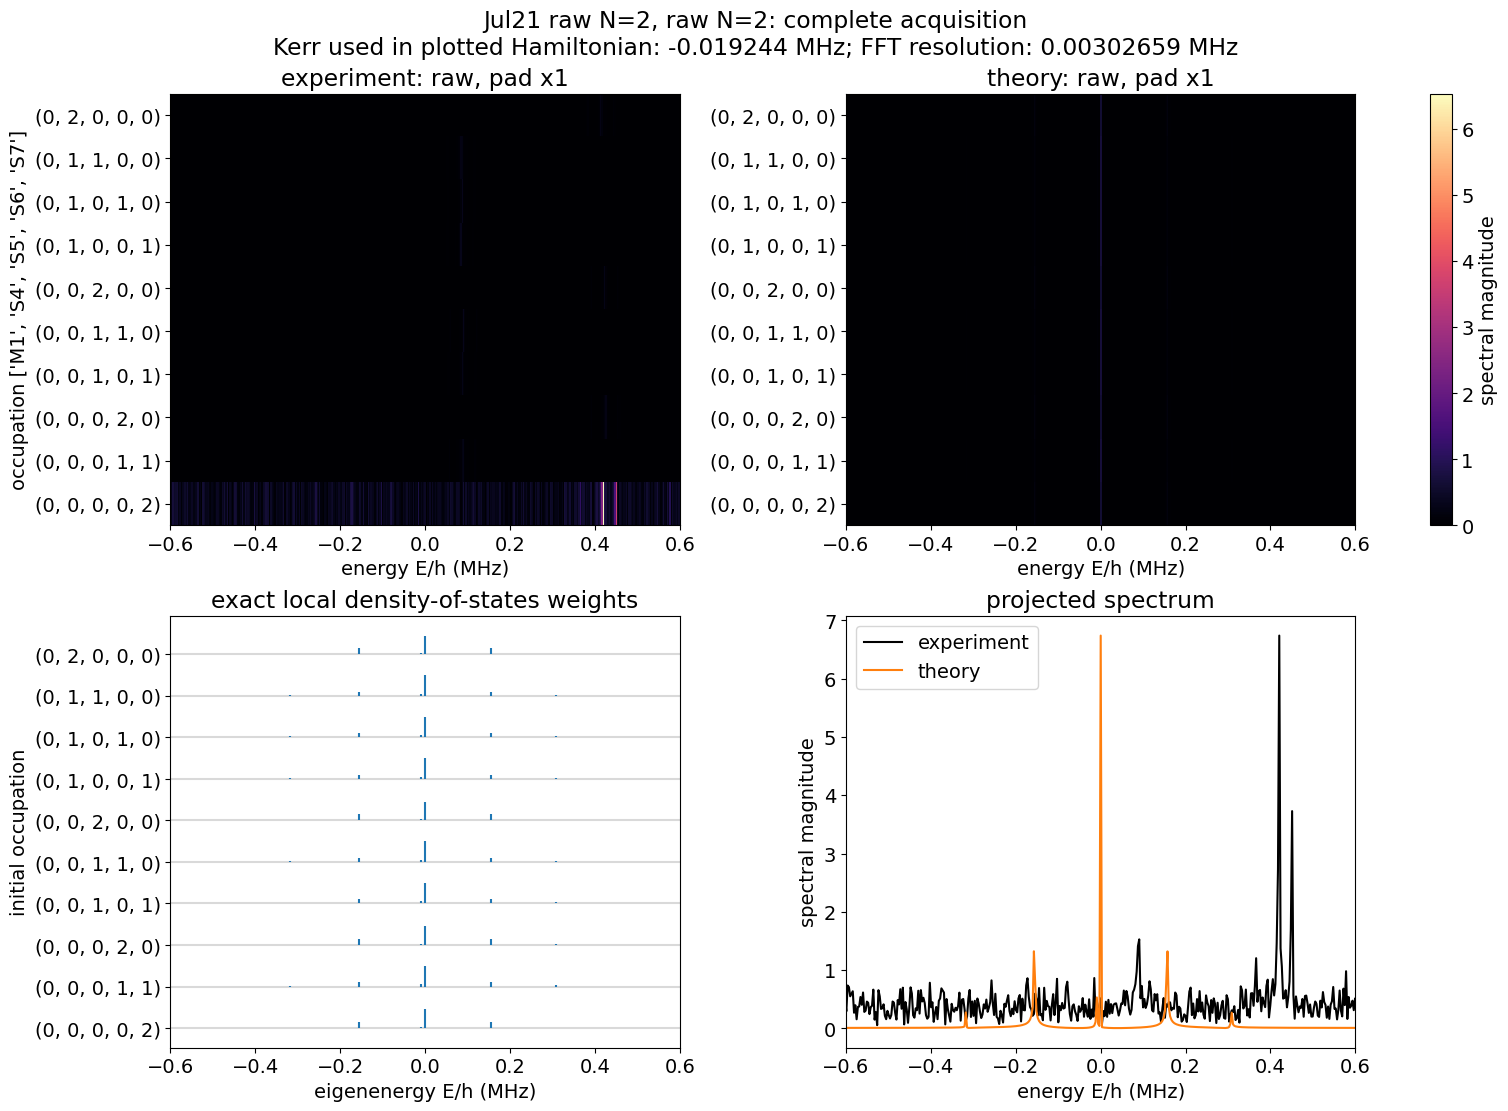

In [6]:
# Jul21 raw N=2 / raw N=2: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Jul21 raw N=2'
h5_group = 'raw N=2'
h5_project = '260526_qsim_darkmode'
h5_calibration_job_ids = []
h5_spectroscopy_job_ids = [
    'JOB-20260721-00267', 'JOB-20260721-00271', 'JOB-20260721-00269', 'JOB-20260721-00273',
    'JOB-20260721-00275', 'JOB-20260721-00279', 'JOB-20260721-00277', 'JOB-20260721-00281',
    'JOB-20260721-00283', 'JOB-20260721-00287', 'JOB-20260721-00285', 'JOB-20260721-00289',
    'JOB-20260721-00291', 'JOB-20260721-00295', 'JOB-20260721-00293', 'JOB-20260721-00297',
    'JOB-20260721-00299', 'JOB-20260721-00303', 'JOB-20260721-00301', 'JOB-20260721-00305',
    'JOB-20260721-00307', 'JOB-20260721-00311', 'JOB-20260721-00309', 'JOB-20260721-00313',
    'JOB-20260721-00315', 'JOB-20260721-00319', 'JOB-20260721-00317', 'JOB-20260721-00321',
    'JOB-20260721-00323', 'JOB-20260721-00327', 'JOB-20260721-00325', 'JOB-20260721-00329',
    'JOB-20260721-00331', 'JOB-20260721-00335', 'JOB-20260721-00333', 'JOB-20260721-00337',
    'JOB-20260721-00339', 'JOB-20260721-00343', 'JOB-20260721-00341', 'JOB-20260721-00345',
]
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_hardware = dict(floquet_cycle_us=0.4130059523809524, couplings_MHz=[0.078125] * 4, decoder_cycle_us=0.4130059523809524, source="July 21 saved analysis T/g")
h5_legacy_plus = True
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


## Jul22 N=1


### Jul22 N=1 / N=1


In [ ]:
# Jul22 N=1 / N=1: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Jul22 N=1'
h5_group = 'N=1'
h5_project = '260526_qsim_darkmode'
h5_calibration_job_ids = h5_job_ids(20260722, 557, 566)
h5_spectroscopy_job_ids = h5_job_ids(20260722, 577, 595)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_hardware = dict(floquet_cycle_us=0.4, couplings_MHz=[0.01] * 4, decoder_cycle_us=0.4, source="DUMMY T/g for Jul22 N=1")
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


## Jul22 N=2


### Jul22 N=2 / N=2


In [ ]:
# Jul22 N=2 / N=2: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Jul22 N=2'
h5_group = 'N=2'
h5_project = '260526_qsim_darkmode'
h5_calibration_job_ids = h5_job_ids(20260722, 35, 64)
h5_spectroscopy_job_ids = h5_job_ids(20260722, 215, 244)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_hardware = dict(floquet_cycle_us=0.4, couplings_MHz=[0.01] * 4, decoder_cycle_us=0.4, source="DUMMY T/g for Jul22 N=2")
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


## Jul22 N=2 supplement


### Jul22 N=2 supplement / N=2 supplement


In [ ]:
# Jul22 N=2 supplement / N=2 supplement: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Jul22 N=2 supplement'
h5_group = 'N=2 supplement'
h5_project = '260526_qsim_darkmode'
h5_calibration_job_ids = ['JOB-20260722-00425', 'JOB-20260722-00426']
h5_spectroscopy_job_ids = h5_job_ids(20260722, 452, 454)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_hardware = dict(floquet_cycle_us=0.4, couplings_MHz=[0.01] * 4, decoder_cycle_us=0.4, source="DUMMY T/g for Jul22 N=2 supplement")
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


## Jul23 N=3


### Jul23 N=3 / N=3


In [ ]:
# Jul23 N=3 / N=3: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Jul23 N=3'
h5_group = 'N=3'
h5_project = '260526_qsim_darkmode'
h5_calibration_job_ids = (
    h5_job_ids(20260722, 683, 712)
    + h5_job_ids(20260723, 1, 40)
)
h5_spectroscopy_job_ids = (
    h5_job_ids(20260723, 48, 85)
    + h5_job_ids(20260723, 87, 149, 2)
)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_hardware = dict(floquet_cycle_us=0.4, couplings_MHz=[0.01] * 4, decoder_cycle_us=0.4, source="DUMMY T/g for Jul23 N=3")
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


## Jul22 N=4


### Jul22 N=4 / N=4


In [ ]:
# Jul22 N=4 / N=4: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Jul22 N=4'
h5_group = 'N=4'
h5_project = '260526_qsim_darkmode'
h5_calibration_job_ids = h5_job_ids(20260721, 423, 432)
h5_spectroscopy_job_ids = h5_job_ids(20260722, 5, 14)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_hardware = dict(floquet_cycle_us=0.4, couplings_MHz=[0.01] * 4, decoder_cycle_us=0.4, source="DUMMY T/g for Jul22 N=4")
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


## Aug15 four-realization


### Aug15 four-realization / four-realization


In [ ]:
# Aug15 four-realization / four-realization: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug15 four-realization'
h5_group = 'four-realization'
h5_project = '260814_qsim_encspec'
h5_calibration_job_ids = []
h5_spectroscopy_job_ids = h5_job_ids(20260815, 9, 16)
h5_floquet_version = "CFG-FL-20260814-00076"
h5_station = h5_load_offline_station(h5_floquet_version)
h5_hardware = dict(floquet_cycle_us=0.4, couplings_MHz=[0.01] * 4, decoder_cycle_us=0.4, source="DUMMY T/g: August Floquet CSV unavailable")
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


## Aug15-17 N=3 and disorder


### Aug15-17 N=3 and disorder / N=3


In [ ]:
# Aug15-17 N=3 and disorder / N=3: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug15-17 N=3 and disorder'
h5_group = 'N=3'
h5_project = '260526_qsim_darkmode'
h5_calibration_job_ids = h5_job_ids(20260815, 113, 182)
h5_spectroscopy_job_ids = (
    h5_job_ids(20260815, 183, 242)
    + h5_job_ids(20260816, 1, 10)
)
h5_floquet_version = "CFG-FL-20260814-00076"
h5_station = h5_load_offline_station(h5_floquet_version)
h5_hardware = dict(floquet_cycle_us=0.4, couplings_MHz=[0.01] * 4, decoder_cycle_us=0.4, source="DUMMY T/g: August Floquet CSV unavailable")
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug15-17 N=3 and disorder / r=0


In [ ]:
# Aug15-17 N=3 and disorder / r=0: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug15-17 N=3 and disorder'
h5_group = 'r=0'
h5_project = '260526_qsim_darkmode'
h5_calibration_job_ids = h5_job_ids(20260815, 113, 182)
h5_spectroscopy_job_ids = h5_job_ids(20260816, 13, 32)
h5_floquet_version = "CFG-FL-20260814-00076"
h5_station = h5_load_offline_station(h5_floquet_version)
h5_hardware = dict(floquet_cycle_us=0.4, couplings_MHz=[0.01] * 4, decoder_cycle_us=0.4, source="DUMMY T/g: August Floquet CSV unavailable")
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug15-17 N=3 and disorder / r=1


In [ ]:
# Aug15-17 N=3 and disorder / r=1: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug15-17 N=3 and disorder'
h5_group = 'r=1'
h5_project = '260526_qsim_darkmode'
h5_calibration_job_ids = h5_job_ids(20260815, 113, 182)
h5_spectroscopy_job_ids = h5_job_ids(20260816, 33, 52)
h5_floquet_version = "CFG-FL-20260814-00076"
h5_station = h5_load_offline_station(h5_floquet_version)
h5_hardware = dict(floquet_cycle_us=0.4, couplings_MHz=[0.01] * 4, decoder_cycle_us=0.4, source="DUMMY T/g: August Floquet CSV unavailable")
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug15-17 N=3 and disorder / r=2


In [ ]:
# Aug15-17 N=3 and disorder / r=2: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug15-17 N=3 and disorder'
h5_group = 'r=2'
h5_project = '260526_qsim_darkmode'
h5_calibration_job_ids = h5_job_ids(20260815, 113, 182)
h5_spectroscopy_job_ids = h5_job_ids(20260816, 53, 72)
h5_floquet_version = "CFG-FL-20260814-00076"
h5_station = h5_load_offline_station(h5_floquet_version)
h5_hardware = dict(floquet_cycle_us=0.4, couplings_MHz=[0.01] * 4, decoder_cycle_us=0.4, source="DUMMY T/g: August Floquet CSV unavailable")
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug15-17 N=3 and disorder / r=3


In [ ]:
# Aug15-17 N=3 and disorder / r=3: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug15-17 N=3 and disorder'
h5_group = 'r=3'
h5_project = '260526_qsim_darkmode'
h5_calibration_job_ids = h5_job_ids(20260815, 113, 182)
h5_spectroscopy_job_ids = h5_job_ids(20260817, 1, 20)
h5_floquet_version = "CFG-FL-20260814-00076"
h5_station = h5_load_offline_station(h5_floquet_version)
h5_hardware = dict(floquet_cycle_us=0.4, couplings_MHz=[0.01] * 4, decoder_cycle_us=0.4, source="DUMMY T/g: August Floquet CSV unavailable")
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


## Aug26 four-realization


### Aug26 four-realization / four-realization


In [ ]:
# Aug26 four-realization / four-realization: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug26 four-realization'
h5_group = 'four-realization'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = []
h5_spectroscopy_job_ids = h5_job_ids(20260826, 67, 78)
# Lab note 8/20/2026: this exact JOB list follows the post-calibration config snapshot.
h5_floquet_version = 'CFG-FL-20260825-00094'
h5_station = h5_load_offline_station(h5_floquet_version)
h5_hardware = dict(floquet_cycle_us=0.4, couplings_MHz=[0.01] * 4, decoder_cycle_us=0.4, source="DUMMY T/g for Aug26 four-realization")
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


## Aug28-30 diagonal disorder


### Aug28-30 diagonal disorder / r=0


In [ ]:
# Aug28-30 diagonal disorder / r=0: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug28-30 diagonal disorder'
h5_group = 'r=0'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260828, 289, 358)
h5_spectroscopy_job_ids = h5_job_ids(20260829, 16, 35)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_hardware = dict(floquet_cycle_us=0.4, couplings_MHz=[0.01] * 4, decoder_cycle_us=0.4, source="DUMMY T/g for Aug28-30 diagonal disorder")
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug28-30 diagonal disorder / r=1


In [ ]:
# Aug28-30 diagonal disorder / r=1: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug28-30 diagonal disorder'
h5_group = 'r=1'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260828, 289, 358)
h5_spectroscopy_job_ids = h5_job_ids(20260829, 36, 55)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_hardware = dict(floquet_cycle_us=0.4, couplings_MHz=[0.01] * 4, decoder_cycle_us=0.4, source="DUMMY T/g for Aug28-30 diagonal disorder")
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug28-30 diagonal disorder / r=2


In [ ]:
# Aug28-30 diagonal disorder / r=2: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug28-30 diagonal disorder'
h5_group = 'r=2'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260828, 289, 358)
h5_spectroscopy_job_ids = h5_job_ids(20260829, 56, 75)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_hardware = dict(floquet_cycle_us=0.4, couplings_MHz=[0.01] * 4, decoder_cycle_us=0.4, source="DUMMY T/g for Aug28-30 diagonal disorder")
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug28-30 diagonal disorder / r=3


In [ ]:
# Aug28-30 diagonal disorder / r=3: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug28-30 diagonal disorder'
h5_group = 'r=3'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260828, 289, 358)
h5_spectroscopy_job_ids = h5_job_ids(20260829, 76, 95)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_hardware = dict(floquet_cycle_us=0.4, couplings_MHz=[0.01] * 4, decoder_cycle_us=0.4, source="DUMMY T/g for Aug28-30 diagonal disorder")
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug28-30 diagonal disorder / r=4


In [ ]:
# Aug28-30 diagonal disorder / r=4: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug28-30 diagonal disorder'
h5_group = 'r=4'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260828, 289, 358)
h5_spectroscopy_job_ids = h5_job_ids(20260829, 96, 115)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_hardware = dict(floquet_cycle_us=0.4, couplings_MHz=[0.01] * 4, decoder_cycle_us=0.4, source="DUMMY T/g for Aug28-30 diagonal disorder")
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug28-30 diagonal disorder / r=5


In [ ]:
# Aug28-30 diagonal disorder / r=5: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug28-30 diagonal disorder'
h5_group = 'r=5'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260828, 289, 358)
h5_spectroscopy_job_ids = h5_job_ids(20260829, 116, 135)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_hardware = dict(floquet_cycle_us=0.4, couplings_MHz=[0.01] * 4, decoder_cycle_us=0.4, source="DUMMY T/g for Aug28-30 diagonal disorder")
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug28-30 diagonal disorder / r=6


In [ ]:
# Aug28-30 diagonal disorder / r=6: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug28-30 diagonal disorder'
h5_group = 'r=6'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260828, 289, 358)
h5_spectroscopy_job_ids = h5_job_ids(20260829, 136, 155)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_hardware = dict(floquet_cycle_us=0.4, couplings_MHz=[0.01] * 4, decoder_cycle_us=0.4, source="DUMMY T/g for Aug28-30 diagonal disorder")
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug28-30 diagonal disorder / r=7


In [ ]:
# Aug28-30 diagonal disorder / r=7: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug28-30 diagonal disorder'
h5_group = 'r=7'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260828, 289, 358)
h5_spectroscopy_job_ids = h5_job_ids(20260829, 156, 175)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_hardware = dict(floquet_cycle_us=0.4, couplings_MHz=[0.01] * 4, decoder_cycle_us=0.4, source="DUMMY T/g for Aug28-30 diagonal disorder")
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug28-30 diagonal disorder / r=8


In [ ]:
# Aug28-30 diagonal disorder / r=8: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug28-30 diagonal disorder'
h5_group = 'r=8'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260828, 289, 358)
h5_spectroscopy_job_ids = h5_job_ids(20260829, 176, 195)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_hardware = dict(floquet_cycle_us=0.4, couplings_MHz=[0.01] * 4, decoder_cycle_us=0.4, source="DUMMY T/g for Aug28-30 diagonal disorder")
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug28-30 diagonal disorder / r=9


In [ ]:
# Aug28-30 diagonal disorder / r=9: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug28-30 diagonal disorder'
h5_group = 'r=9'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260828, 289, 358)
h5_spectroscopy_job_ids = h5_job_ids(20260829, 196, 215)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_hardware = dict(floquet_cycle_us=0.4, couplings_MHz=[0.01] * 4, decoder_cycle_us=0.4, source="DUMMY T/g for Aug28-30 diagonal disorder")
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug28-30 diagonal disorder / r=10


In [ ]:
# Aug28-30 diagonal disorder / r=10: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug28-30 diagonal disorder'
h5_group = 'r=10'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260828, 289, 358)
h5_spectroscopy_job_ids = h5_job_ids(20260829, 216, 235)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_hardware = dict(floquet_cycle_us=0.4, couplings_MHz=[0.01] * 4, decoder_cycle_us=0.4, source="DUMMY T/g for Aug28-30 diagonal disorder")
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug28-30 diagonal disorder / r=11


In [ ]:
# Aug28-30 diagonal disorder / r=11: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug28-30 diagonal disorder'
h5_group = 'r=11'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260828, 289, 358)
h5_spectroscopy_job_ids = h5_job_ids(20260829, 236, 255)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_hardware = dict(floquet_cycle_us=0.4, couplings_MHz=[0.01] * 4, decoder_cycle_us=0.4, source="DUMMY T/g for Aug28-30 diagonal disorder")
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug28-30 diagonal disorder / r=12


In [ ]:
# Aug28-30 diagonal disorder / r=12: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug28-30 diagonal disorder'
h5_group = 'r=12'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260828, 289, 358)
h5_spectroscopy_job_ids = (
    h5_job_ids(20260829, 256, 271)
    + h5_job_ids(20260830, 1, 4)
)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_hardware = dict(floquet_cycle_us=0.4, couplings_MHz=[0.01] * 4, decoder_cycle_us=0.4, source="DUMMY T/g for Aug28-30 diagonal disorder")
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug28-30 diagonal disorder / r=13


In [ ]:
# Aug28-30 diagonal disorder / r=13: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug28-30 diagonal disorder'
h5_group = 'r=13'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260828, 289, 358)
h5_spectroscopy_job_ids = h5_job_ids(20260830, 5, 24)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_hardware = dict(floquet_cycle_us=0.4, couplings_MHz=[0.01] * 4, decoder_cycle_us=0.4, source="DUMMY T/g for Aug28-30 diagonal disorder")
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug28-30 diagonal disorder / r=14


In [ ]:
# Aug28-30 diagonal disorder / r=14: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug28-30 diagonal disorder'
h5_group = 'r=14'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260828, 289, 358)
h5_spectroscopy_job_ids = h5_job_ids(20260830, 25, 44)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_hardware = dict(floquet_cycle_us=0.4, couplings_MHz=[0.01] * 4, decoder_cycle_us=0.4, source="DUMMY T/g for Aug28-30 diagonal disorder")
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug28-30 diagonal disorder / r=15


In [ ]:
# Aug28-30 diagonal disorder / r=15: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug28-30 diagonal disorder'
h5_group = 'r=15'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260828, 289, 358)
h5_spectroscopy_job_ids = h5_job_ids(20260830, 45, 64)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_hardware = dict(floquet_cycle_us=0.4, couplings_MHz=[0.01] * 4, decoder_cycle_us=0.4, source="DUMMY T/g for Aug28-30 diagonal disorder")
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug28-30 diagonal disorder / r=16


In [ ]:
# Aug28-30 diagonal disorder / r=16: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug28-30 diagonal disorder'
h5_group = 'r=16'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260828, 289, 358)
h5_spectroscopy_job_ids = h5_job_ids(20260830, 65, 84)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_hardware = dict(floquet_cycle_us=0.4, couplings_MHz=[0.01] * 4, decoder_cycle_us=0.4, source="DUMMY T/g for Aug28-30 diagonal disorder")
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug28-30 diagonal disorder / r=17


In [ ]:
# Aug28-30 diagonal disorder / r=17: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug28-30 diagonal disorder'
h5_group = 'r=17'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260828, 289, 358)
h5_spectroscopy_job_ids = h5_job_ids(20260830, 85, 104)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_hardware = dict(floquet_cycle_us=0.4, couplings_MHz=[0.01] * 4, decoder_cycle_us=0.4, source="DUMMY T/g for Aug28-30 diagonal disorder")
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug28-30 diagonal disorder / r=18


In [ ]:
# Aug28-30 diagonal disorder / r=18: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug28-30 diagonal disorder'
h5_group = 'r=18'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260828, 289, 358)
h5_spectroscopy_job_ids = h5_job_ids(20260830, 105, 124)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_hardware = dict(floquet_cycle_us=0.4, couplings_MHz=[0.01] * 4, decoder_cycle_us=0.4, source="DUMMY T/g for Aug28-30 diagonal disorder")
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Aug28-30 diagonal disorder / r=19


In [ ]:
# Aug28-30 diagonal disorder / r=19: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug28-30 diagonal disorder'
h5_group = 'r=19'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260828, 289, 358)
h5_spectroscopy_job_ids = h5_job_ids(20260830, 125, 135)
h5_floquet_version = None
h5_station = h5_load_offline_station(h5_floquet_version)
h5_hardware = dict(floquet_cycle_us=0.4, couplings_MHz=[0.01] * 4, decoder_cycle_us=0.4, source="DUMMY T/g for Aug28-30 diagonal disorder")
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


## Sep10 K3.6 g29.2


### Sep10 K3.6 g29.2 / r=0


In [ ]:
# Sep10 K3.6 g29.2 / r=0: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep10 K3.6 g29.2'
h5_group = 'r=0'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = (
    h5_job_ids(20260909, 152, 211)
    + h5_job_ids(20260910, 1, 10)
)
h5_spectroscopy_job_ids = (
    h5_job_ids(20260910, 31, 72)
    + h5_job_ids(20260911, 46, 87)
)
# Lab note ties Sep10 JOB-00031..00072 to CFG-FL-20260909-00042.
# The Sep11 JOBs in this same cell have no verified Floquet version.
h5_floquet_version = None  # Archived T/g below already cover these jobs.
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 92 / 430.08
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[1 / (4 * 40 * h5_T_us)] * 4, decoder_cycle_us=h5_T_us, source="Sep07 archived run instructions: 92 ticks / 430.08 MHz; pi_frac 40")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep10 K3.6 g29.2 / r=1


In [ ]:
# Sep10 K3.6 g29.2 / r=1: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep10 K3.6 g29.2'
h5_group = 'r=1'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = (
    h5_job_ids(20260909, 152, 211)
    + h5_job_ids(20260910, 1, 10)
)
h5_spectroscopy_job_ids = h5_job_ids(20260912, 33, 136)
h5_floquet_version = None  # Archived T/g below already cover these jobs.
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 92 / 430.08
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[1 / (4 * 40 * h5_T_us)] * 4, decoder_cycle_us=h5_T_us, source="Sep07 archived run instructions: 92 ticks / 430.08 MHz; pi_frac 40")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep10 K3.6 g29.2 / r=2


In [ ]:
# Sep10 K3.6 g29.2 / r=2: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep10 K3.6 g29.2'
h5_group = 'r=2'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = (
    h5_job_ids(20260909, 152, 211)
    + h5_job_ids(20260910, 1, 10)
)
h5_spectroscopy_job_ids = h5_job_ids(20260912, 137, 241)
h5_floquet_version = None  # Archived T/g below already cover these jobs.
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 92 / 430.08
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[1 / (4 * 40 * h5_T_us)] * 4, decoder_cycle_us=h5_T_us, source="Sep07 archived run instructions: 92 ticks / 430.08 MHz; pi_frac 40")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep10 K3.6 g29.2 / r=3


In [ ]:
# Sep10 K3.6 g29.2 / r=3: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep10 K3.6 g29.2'
h5_group = 'r=3'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = (
    h5_job_ids(20260909, 152, 211)
    + h5_job_ids(20260910, 1, 10)
)
h5_spectroscopy_job_ids = h5_job_ids(20260912, 243, 347)
h5_floquet_version = None  # Archived T/g below already cover these jobs.
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 92 / 430.08
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[1 / (4 * 40 * h5_T_us)] * 4, decoder_cycle_us=h5_T_us, source="Sep07 archived run instructions: 92 ticks / 430.08 MHz; pi_frac 40")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep10 K3.6 g29.2 / r=4


In [ ]:
# Sep10 K3.6 g29.2 / r=4: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep10 K3.6 g29.2'
h5_group = 'r=4'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = (
    h5_job_ids(20260909, 152, 211)
    + h5_job_ids(20260910, 1, 10)
)
h5_spectroscopy_job_ids = (
    h5_job_ids(20260912, 348, 419)
    + h5_job_ids(20260913, 1, 64)
)
h5_floquet_version = None  # Archived T/g below already cover these jobs.
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 92 / 430.08
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[1 / (4 * 40 * h5_T_us)] * 4, decoder_cycle_us=h5_T_us, source="Sep07 archived run instructions: 92 ticks / 430.08 MHz; pi_frac 40")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep10 K3.6 g29.2 / r=5


In [ ]:
# Sep10 K3.6 g29.2 / r=5: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep10 K3.6 g29.2'
h5_group = 'r=5'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = (
    h5_job_ids(20260909, 152, 211)
    + h5_job_ids(20260910, 1, 10)
)
h5_spectroscopy_job_ids = h5_job_ids(20260913, 65, 168)
h5_floquet_version = None  # Archived T/g below already cover these jobs.
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 92 / 430.08
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[1 / (4 * 40 * h5_T_us)] * 4, decoder_cycle_us=h5_T_us, source="Sep07 archived run instructions: 92 ticks / 430.08 MHz; pi_frac 40")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep10 K3.6 g29.2 / r=6


In [ ]:
# Sep10 K3.6 g29.2 / r=6: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep10 K3.6 g29.2'
h5_group = 'r=6'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = (
    h5_job_ids(20260909, 152, 211)
    + h5_job_ids(20260910, 1, 10)
)
h5_spectroscopy_job_ids = h5_job_ids(20260913, 169, 273)
h5_floquet_version = None  # Archived T/g below already cover these jobs.
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 92 / 430.08
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[1 / (4 * 40 * h5_T_us)] * 4, decoder_cycle_us=h5_T_us, source="Sep07 archived run instructions: 92 ticks / 430.08 MHz; pi_frac 40")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep10 K3.6 g29.2 / r=7


In [ ]:
# Sep10 K3.6 g29.2 / r=7: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep10 K3.6 g29.2'
h5_group = 'r=7'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = (
    h5_job_ids(20260909, 152, 211)
    + h5_job_ids(20260910, 1, 10)
)
h5_spectroscopy_job_ids = h5_job_ids(20260913, 274, 378)
h5_floquet_version = None  # Archived T/g below already cover these jobs.
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 92 / 430.08
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[1 / (4 * 40 * h5_T_us)] * 4, decoder_cycle_us=h5_T_us, source="Sep07 archived run instructions: 92 ticks / 430.08 MHz; pi_frac 40")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep10 K3.6 g29.2 / r=8


In [ ]:
# Sep10 K3.6 g29.2 / r=8: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep10 K3.6 g29.2'
h5_group = 'r=8'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = (
    h5_job_ids(20260909, 152, 211)
    + h5_job_ids(20260910, 1, 10)
)
h5_spectroscopy_job_ids = (
    h5_job_ids(20260913, 380, 399)
    + h5_job_ids(20260914, 1, 84)
)
h5_floquet_version = None  # Archived T/g below already cover these jobs.
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 92 / 430.08
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[1 / (4 * 40 * h5_T_us)] * 4, decoder_cycle_us=h5_T_us, source="Sep07 archived run instructions: 92 ticks / 430.08 MHz; pi_frac 40")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


## Sep07 K52.3 g29.2


### Sep07 K52.3 g29.2 / r=0


In [ ]:
# Sep07 K52.3 g29.2 / r=0: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep07 K52.3 g29.2'
h5_group = 'r=0'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260907, 199, 268)
h5_spectroscopy_job_ids = h5_job_ids(20260907, 304, 333)
h5_floquet_version = None  # Archived T/g below already cover these jobs.
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 92 / 430.08
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[1 / (4 * 40 * h5_T_us)] * 4, decoder_cycle_us=h5_T_us, source="Sep07 archived run instructions: 92 ticks / 430.08 MHz; pi_frac 40")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep07 K52.3 g29.2 / r=1


In [ ]:
# Sep07 K52.3 g29.2 / r=1: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep07 K52.3 g29.2'
h5_group = 'r=1'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260907, 199, 268)
h5_spectroscopy_job_ids = h5_job_ids(20260907, 334, 363)
h5_floquet_version = None  # Archived T/g below already cover these jobs.
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 92 / 430.08
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[1 / (4 * 40 * h5_T_us)] * 4, decoder_cycle_us=h5_T_us, source="Sep07 archived run instructions: 92 ticks / 430.08 MHz; pi_frac 40")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep07 K52.3 g29.2 / r=2


In [ ]:
# Sep07 K52.3 g29.2 / r=2: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep07 K52.3 g29.2'
h5_group = 'r=2'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260907, 199, 268)
h5_spectroscopy_job_ids = h5_job_ids(20260907, 364, 393)
h5_floquet_version = None  # Archived T/g below already cover these jobs.
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 92 / 430.08
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[1 / (4 * 40 * h5_T_us)] * 4, decoder_cycle_us=h5_T_us, source="Sep07 archived run instructions: 92 ticks / 430.08 MHz; pi_frac 40")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep07 K52.3 g29.2 / r=3


In [ ]:
# Sep07 K52.3 g29.2 / r=3: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep07 K52.3 g29.2'
h5_group = 'r=3'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260907, 199, 268)
h5_spectroscopy_job_ids = (
    h5_job_ids(20260907, 406, 415)
    + h5_job_ids(20260908, 1, 20)
)
h5_floquet_version = None  # Archived T/g below already cover these jobs.
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 92 / 430.08
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[1 / (4 * 40 * h5_T_us)] * 4, decoder_cycle_us=h5_T_us, source="Sep07 archived run instructions: 92 ticks / 430.08 MHz; pi_frac 40")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep07 K52.3 g29.2 / r=4


In [ ]:
# Sep07 K52.3 g29.2 / r=4: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep07 K52.3 g29.2'
h5_group = 'r=4'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260907, 199, 268)
h5_spectroscopy_job_ids = h5_job_ids(20260908, 21, 50)
h5_floquet_version = None  # Archived T/g below already cover these jobs.
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 92 / 430.08
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[1 / (4 * 40 * h5_T_us)] * 4, decoder_cycle_us=h5_T_us, source="Sep07 archived run instructions: 92 ticks / 430.08 MHz; pi_frac 40")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep07 K52.3 g29.2 / r=5


In [ ]:
# Sep07 K52.3 g29.2 / r=5: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep07 K52.3 g29.2'
h5_group = 'r=5'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260907, 199, 268)
h5_spectroscopy_job_ids = h5_job_ids(20260908, 51, 80)
h5_floquet_version = None  # Archived T/g below already cover these jobs.
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 92 / 430.08
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[1 / (4 * 40 * h5_T_us)] * 4, decoder_cycle_us=h5_T_us, source="Sep07 archived run instructions: 92 ticks / 430.08 MHz; pi_frac 40")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


## Sep05 K3.6 g30


### Sep05 K3.6 g30 / r=0


In [ ]:
# Sep05 K3.6 g30 / r=0: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep05 K3.6 g30'
h5_group = 'r=0'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260905, 75, 144)
h5_spectroscopy_job_ids = h5_job_ids(20260905, 145, 159)
# Lab note lists these exact JOB IDs after this Floquet config snapshot.
h5_floquet_version = 'CFG-FL-20260905-00045'
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 92 / 430.08
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[1 / (4 * 40 * h5_T_us)] * 4, decoder_cycle_us=0.21963713369963367, source="Sep05 archived compiled timing and decoder-frame audit")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep05 K3.6 g30 / r=1


In [ ]:
# Sep05 K3.6 g30 / r=1: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep05 K3.6 g30'
h5_group = 'r=1'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260905, 75, 144)
h5_spectroscopy_job_ids = h5_job_ids(20260905, 160, 174)
# Lab note lists these exact JOB IDs after this Floquet config snapshot.
h5_floquet_version = 'CFG-FL-20260905-00045'
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 92 / 430.08
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[1 / (4 * 40 * h5_T_us)] * 4, decoder_cycle_us=0.21963713369963367, source="Sep05 archived compiled timing and decoder-frame audit")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


## Sep01 K44 g15


### Sep01 K44 g15 / r=0


In [ ]:
# Sep01 K44 g15 / r=0: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep01 K44 g15'
h5_group = 'r=0'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260831, 479, 548)
h5_spectroscopy_job_ids = h5_job_ids(20260901, 3, 12)
# Lab note lists these exact JOB IDs after this Floquet config snapshot.
h5_floquet_version = 'CFG-FL-20260831-00092'
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 0.41351877289377287
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[0.015114186851211072] * 4, decoder_cycle_us=h5_T_us, source="Archived acquisition-time g15 analysis export")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep01 K44 g15 / r=1


In [ ]:
# Sep01 K44 g15 / r=1: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep01 K44 g15'
h5_group = 'r=1'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260831, 479, 548)
h5_spectroscopy_job_ids = h5_job_ids(20260901, 13, 22)
# Lab note lists these exact JOB IDs after this Floquet config snapshot.
h5_floquet_version = 'CFG-FL-20260831-00092'
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 0.41351877289377287
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[0.015114186851211072] * 4, decoder_cycle_us=h5_T_us, source="Archived acquisition-time g15 analysis export")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep01 K44 g15 / r=2


In [ ]:
# Sep01 K44 g15 / r=2: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep01 K44 g15'
h5_group = 'r=2'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260831, 479, 548)
h5_spectroscopy_job_ids = h5_job_ids(20260901, 23, 32)
# Lab note lists these exact JOB IDs after this Floquet config snapshot.
h5_floquet_version = 'CFG-FL-20260831-00092'
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 0.41351877289377287
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[0.015114186851211072] * 4, decoder_cycle_us=h5_T_us, source="Archived acquisition-time g15 analysis export")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep01 K44 g15 / r=3


In [ ]:
# Sep01 K44 g15 / r=3: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep01 K44 g15'
h5_group = 'r=3'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260831, 479, 548)
h5_spectroscopy_job_ids = h5_job_ids(20260901, 33, 42)
# Lab note lists these exact JOB IDs after this Floquet config snapshot.
h5_floquet_version = 'CFG-FL-20260831-00092'
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 0.41351877289377287
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[0.015114186851211072] * 4, decoder_cycle_us=h5_T_us, source="Archived acquisition-time g15 analysis export")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep01 K44 g15 / r=4


In [ ]:
# Sep01 K44 g15 / r=4: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep01 K44 g15'
h5_group = 'r=4'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260831, 479, 548)
h5_spectroscopy_job_ids = h5_job_ids(20260901, 43, 52)
# Lab note lists these exact JOB IDs after this Floquet config snapshot.
h5_floquet_version = 'CFG-FL-20260831-00092'
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 0.41351877289377287
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[0.015114186851211072] * 4, decoder_cycle_us=h5_T_us, source="Archived acquisition-time g15 analysis export")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


## Sep02 K20 g15


### Sep02 K20 g15 / r=0


In [ ]:
# Sep02 K20 g15 / r=0: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02 K20 g15'
h5_group = 'r=0'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 1, 70)
h5_spectroscopy_job_ids = h5_job_ids(20260902, 71, 80)
# Lab note lists these exact JOB IDs after this Floquet config snapshot.
h5_floquet_version = 'CFG-FL-20260831-00093'
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 0.41351877289377287
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[0.015114186851211072] * 4, decoder_cycle_us=h5_T_us, source="Archived acquisition-time g15 analysis export")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02 K20 g15 / r=1


In [ ]:
# Sep02 K20 g15 / r=1: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02 K20 g15'
h5_group = 'r=1'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 1, 70)
h5_spectroscopy_job_ids = h5_job_ids(20260902, 81, 90)
# Lab note lists these exact JOB IDs after this Floquet config snapshot.
h5_floquet_version = 'CFG-FL-20260831-00093'
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 0.41351877289377287
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[0.015114186851211072] * 4, decoder_cycle_us=h5_T_us, source="Archived acquisition-time g15 analysis export")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02 K20 g15 / r=2


In [ ]:
# Sep02 K20 g15 / r=2: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02 K20 g15'
h5_group = 'r=2'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 1, 70)
h5_spectroscopy_job_ids = (
    h5_job_ids(20260902, 91, 94)
    + [
        'JOB-20260902-00096', 'JOB-20260902-00097', 'JOB-20260902-00099', 'JOB-20260902-00100',
        'JOB-20260902-00102', 'JOB-20260902-00103',
    ]
)
# Lab note lists these exact JOB IDs after this Floquet config snapshot.
h5_floquet_version = 'CFG-FL-20260831-00093'
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 0.41351877289377287
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[0.015114186851211072] * 4, decoder_cycle_us=h5_T_us, source="Archived acquisition-time g15 analysis export")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02 K20 g15 / r=3


In [ ]:
# Sep02 K20 g15 / r=3: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02 K20 g15'
h5_group = 'r=3'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 1, 70)
h5_spectroscopy_job_ids = [
    'JOB-20260902-00105', 'JOB-20260902-00106', 'JOB-20260902-00108', 'JOB-20260902-00109',
    'JOB-20260902-00111', 'JOB-20260902-00112', 'JOB-20260902-00114', 'JOB-20260902-00115',
    'JOB-20260902-00117', 'JOB-20260902-00118',
]
# Lab note lists these exact JOB IDs after this Floquet config snapshot.
h5_floquet_version = 'CFG-FL-20260831-00093'
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 0.41351877289377287
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[0.015114186851211072] * 4, decoder_cycle_us=h5_T_us, source="Archived acquisition-time g15 analysis export")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02 K20 g15 / r=4


In [ ]:
# Sep02 K20 g15 / r=4: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02 K20 g15'
h5_group = 'r=4'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 1, 70)
h5_spectroscopy_job_ids = [
    'JOB-20260902-00120', 'JOB-20260902-00121', 'JOB-20260902-00123', 'JOB-20260902-00124',
    'JOB-20260902-00126', 'JOB-20260902-00127', 'JOB-20260902-00129', 'JOB-20260902-00130',
    'JOB-20260902-00132', 'JOB-20260902-00133',
]
# Lab note lists these exact JOB IDs after this Floquet config snapshot.
h5_floquet_version = 'CFG-FL-20260831-00093'
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 0.41351877289377287
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[0.015114186851211072] * 4, decoder_cycle_us=h5_T_us, source="Archived acquisition-time g15 analysis export")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


## Sep02-04 K3.6 g15


### Sep02-04 K3.6 g15 / r=0


In [ ]:
# Sep02-04 K3.6 g15 / r=0: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02-04 K3.6 g15'
h5_group = 'r=0'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 768, 837)
h5_spectroscopy_job_ids = (
    ['JOB-20260902-00840', 'JOB-20260902-00841']
    + h5_job_ids(20260903, 1, 13)
)
h5_floquet_version = None  # Archived T/g below already cover these jobs.
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 0.41351877289377287
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[0.015114186851211072] * 4, decoder_cycle_us=h5_T_us, source="Archived acquisition-time g15 analysis export")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02-04 K3.6 g15 / r=1


In [ ]:
# Sep02-04 K3.6 g15 / r=1: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02-04 K3.6 g15'
h5_group = 'r=1'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 768, 837)
h5_spectroscopy_job_ids = h5_job_ids(20260903, 14, 28)
h5_floquet_version = None  # Archived T/g below already cover these jobs.
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 0.41351877289377287
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[0.015114186851211072] * 4, decoder_cycle_us=h5_T_us, source="Archived acquisition-time g15 analysis export")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02-04 K3.6 g15 / r=2


In [ ]:
# Sep02-04 K3.6 g15 / r=2: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02-04 K3.6 g15'
h5_group = 'r=2'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 768, 837)
h5_spectroscopy_job_ids = h5_job_ids(20260903, 29, 43)
h5_floquet_version = None  # Archived T/g below already cover these jobs.
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 0.41351877289377287
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[0.015114186851211072] * 4, decoder_cycle_us=h5_T_us, source="Archived acquisition-time g15 analysis export")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02-04 K3.6 g15 / r=3


In [ ]:
# Sep02-04 K3.6 g15 / r=3: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02-04 K3.6 g15'
h5_group = 'r=3'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 768, 837)
h5_spectroscopy_job_ids = h5_job_ids(20260903, 44, 58)
h5_floquet_version = None  # Archived T/g below already cover these jobs.
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 0.41351877289377287
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[0.015114186851211072] * 4, decoder_cycle_us=h5_T_us, source="Archived acquisition-time g15 analysis export")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02-04 K3.6 g15 / r=4


In [ ]:
# Sep02-04 K3.6 g15 / r=4: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02-04 K3.6 g15'
h5_group = 'r=4'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 768, 837)
h5_spectroscopy_job_ids = [
    'JOB-20260903-00059', 'JOB-20260903-00060', 'JOB-20260903-00062', 'JOB-20260903-00063',
    'JOB-20260903-00065', 'JOB-20260903-00066', 'JOB-20260903-00068', 'JOB-20260903-00069',
    'JOB-20260903-00071', 'JOB-20260903-00072', 'JOB-20260903-00074', 'JOB-20260903-00075',
    'JOB-20260903-00077', 'JOB-20260903-00078', 'JOB-20260903-00080',
]
h5_floquet_version = None  # Archived T/g below already cover these jobs.
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 0.41351877289377287
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[0.015114186851211072] * 4, decoder_cycle_us=h5_T_us, source="Archived acquisition-time g15 analysis export")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02-04 K3.6 g15 / r=5


In [ ]:
# Sep02-04 K3.6 g15 / r=5: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02-04 K3.6 g15'
h5_group = 'r=5'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 768, 837)
h5_spectroscopy_job_ids = [
    'JOB-20260903-00082', 'JOB-20260903-00083', 'JOB-20260903-00085', 'JOB-20260903-00086',
    'JOB-20260903-00088', 'JOB-20260903-00089', 'JOB-20260903-00091', 'JOB-20260903-00092',
    'JOB-20260903-00094', 'JOB-20260903-00095', 'JOB-20260903-00097', 'JOB-20260903-00098',
    'JOB-20260903-00100', 'JOB-20260903-00101', 'JOB-20260903-00103',
]
h5_floquet_version = None  # Archived T/g below already cover these jobs.
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 0.41351877289377287
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[0.015114186851211072] * 4, decoder_cycle_us=h5_T_us, source="Archived acquisition-time g15 analysis export")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02-04 K3.6 g15 / r=6


In [ ]:
# Sep02-04 K3.6 g15 / r=6: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02-04 K3.6 g15'
h5_group = 'r=6'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 768, 837)
h5_spectroscopy_job_ids = [
    'JOB-20260903-00105', 'JOB-20260903-00106', 'JOB-20260903-00108', 'JOB-20260903-00109',
    'JOB-20260903-00111', 'JOB-20260903-00112', 'JOB-20260903-00114', 'JOB-20260903-00115',
    'JOB-20260903-00117', 'JOB-20260903-00118', 'JOB-20260903-00120', 'JOB-20260903-00121',
    'JOB-20260903-00123', 'JOB-20260903-00124', 'JOB-20260903-00126',
]
h5_floquet_version = None  # Archived T/g below already cover these jobs.
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 0.41351877289377287
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[0.015114186851211072] * 4, decoder_cycle_us=h5_T_us, source="Archived acquisition-time g15 analysis export")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02-04 K3.6 g15 / r=7


In [ ]:
# Sep02-04 K3.6 g15 / r=7: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02-04 K3.6 g15'
h5_group = 'r=7'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 768, 837)
h5_spectroscopy_job_ids = (
    [
        'JOB-20260903-00128', 'JOB-20260903-00129', 'JOB-20260903-00131', 'JOB-20260903-00132',
        'JOB-20260903-00134', 'JOB-20260903-00135', 'JOB-20260903-00137', 'JOB-20260903-00138',
        'JOB-20260903-00140', 'JOB-20260903-00141', 'JOB-20260903-00143', 'JOB-20260903-00144',
    ]
    + h5_job_ids(20260903, 146, 148)
)
h5_floquet_version = None  # Archived T/g below already cover these jobs.
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 0.41351877289377287
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[0.015114186851211072] * 4, decoder_cycle_us=h5_T_us, source="Archived acquisition-time g15 analysis export")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02-04 K3.6 g15 / r=8


In [ ]:
# Sep02-04 K3.6 g15 / r=8: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02-04 K3.6 g15'
h5_group = 'r=8'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 768, 837)
h5_spectroscopy_job_ids = h5_job_ids(20260903, 149, 163)
h5_floquet_version = None  # Archived T/g below already cover these jobs.
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 0.41351877289377287
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[0.015114186851211072] * 4, decoder_cycle_us=h5_T_us, source="Archived acquisition-time g15 analysis export")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02-04 K3.6 g15 / r=9


In [ ]:
# Sep02-04 K3.6 g15 / r=9: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02-04 K3.6 g15'
h5_group = 'r=9'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 768, 837)
h5_spectroscopy_job_ids = h5_job_ids(20260903, 164, 178)
h5_floquet_version = None  # Archived T/g below already cover these jobs.
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 0.41351877289377287
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[0.015114186851211072] * 4, decoder_cycle_us=h5_T_us, source="Archived acquisition-time g15 analysis export")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02-04 K3.6 g15 / r=10


In [ ]:
# Sep02-04 K3.6 g15 / r=10: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02-04 K3.6 g15'
h5_group = 'r=10'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 768, 837)
h5_spectroscopy_job_ids = h5_job_ids(20260903, 179, 193)
h5_floquet_version = None  # Archived T/g below already cover these jobs.
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 0.41351877289377287
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[0.015114186851211072] * 4, decoder_cycle_us=h5_T_us, source="Archived acquisition-time g15 analysis export")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02-04 K3.6 g15 / r=11


In [ ]:
# Sep02-04 K3.6 g15 / r=11: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02-04 K3.6 g15'
h5_group = 'r=11'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 768, 837)
h5_spectroscopy_job_ids = (
    h5_job_ids(20260903, 194, 203)
    + h5_job_ids(20260904, 1, 5)
)
h5_floquet_version = None  # Archived T/g below already cover these jobs.
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 0.41351877289377287
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[0.015114186851211072] * 4, decoder_cycle_us=h5_T_us, source="Archived acquisition-time g15 analysis export")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02-04 K3.6 g15 / r=12


In [ ]:
# Sep02-04 K3.6 g15 / r=12: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02-04 K3.6 g15'
h5_group = 'r=12'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 768, 837)
h5_spectroscopy_job_ids = h5_job_ids(20260904, 6, 20)
h5_floquet_version = None  # Archived T/g below already cover these jobs.
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 0.41351877289377287
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[0.015114186851211072] * 4, decoder_cycle_us=h5_T_us, source="Archived acquisition-time g15 analysis export")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02-04 K3.6 g15 / r=13


In [ ]:
# Sep02-04 K3.6 g15 / r=13: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02-04 K3.6 g15'
h5_group = 'r=13'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 768, 837)
h5_spectroscopy_job_ids = h5_job_ids(20260904, 21, 35)
h5_floquet_version = None  # Archived T/g below already cover these jobs.
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 0.41351877289377287
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[0.015114186851211072] * 4, decoder_cycle_us=h5_T_us, source="Archived acquisition-time g15 analysis export")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02-04 K3.6 g15 / r=14


In [ ]:
# Sep02-04 K3.6 g15 / r=14: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02-04 K3.6 g15'
h5_group = 'r=14'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 768, 837)
h5_spectroscopy_job_ids = h5_job_ids(20260904, 36, 50)
h5_floquet_version = None  # Archived T/g below already cover these jobs.
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 0.41351877289377287
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[0.015114186851211072] * 4, decoder_cycle_us=h5_T_us, source="Archived acquisition-time g15 analysis export")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02-04 K3.6 g15 / r=15


In [ ]:
# Sep02-04 K3.6 g15 / r=15: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02-04 K3.6 g15'
h5_group = 'r=15'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 768, 837)
h5_spectroscopy_job_ids = h5_job_ids(20260904, 51, 65)
h5_floquet_version = None  # Archived T/g below already cover these jobs.
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 0.41351877289377287
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[0.015114186851211072] * 4, decoder_cycle_us=h5_T_us, source="Archived acquisition-time g15 analysis export")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02-04 K3.6 g15 / r=16


In [ ]:
# Sep02-04 K3.6 g15 / r=16: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02-04 K3.6 g15'
h5_group = 'r=16'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 768, 837)
h5_spectroscopy_job_ids = h5_job_ids(20260904, 66, 80)
h5_floquet_version = None  # Archived T/g below already cover these jobs.
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 0.41351877289377287
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[0.015114186851211072] * 4, decoder_cycle_us=h5_T_us, source="Archived acquisition-time g15 analysis export")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02-04 K3.6 g15 / r=17


In [ ]:
# Sep02-04 K3.6 g15 / r=17: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02-04 K3.6 g15'
h5_group = 'r=17'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 768, 837)
h5_spectroscopy_job_ids = h5_job_ids(20260904, 81, 95)
h5_floquet_version = None  # Archived T/g below already cover these jobs.
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 0.41351877289377287
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[0.015114186851211072] * 4, decoder_cycle_us=h5_T_us, source="Archived acquisition-time g15 analysis export")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)


### Sep02-04 K3.6 g15 / r=18


In [ ]:
# Sep02-04 K3.6 g15 / r=18: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Sep02-04 K3.6 g15'
h5_group = 'r=18'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 768, 837)
h5_spectroscopy_job_ids = h5_job_ids(20260904, 96, 110)
h5_floquet_version = None  # Archived T/g below already cover these jobs.
h5_station = h5_load_offline_station(h5_floquet_version)
h5_T_us = 0.41351877289377287
h5_hardware = dict(floquet_cycle_us=h5_T_us, couplings_MHz=[0.015114186851211072] * 4, decoder_cycle_us=h5_T_us, source="Archived acquisition-time g15 analysis export")
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station, cell_hardware=h5_hardware,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
if h5_spectroscopy_expt is not None:
    if h5_calibration_expt is not None:
        h5_calibration_expt.analyze(stage="calibration")
        h5_calibration_fig = h5_calibration_expt.display()
        h5_calibration_fig.suptitle(f"{h5_name}: calibration")
        notebook_display(h5_calibration_fig)
        plt.close(h5_calibration_fig)

    h5_spectrum = h5_spectroscopy_expt.analyze(
        stage="spectrum", calibration=h5_calibration_expt,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    h5_fig = h5_spectroscopy_expt.display(
        data=h5_spectrum, level_statistics=False
    )
    h5_previous_title = h5_fig._suptitle.get_text() if h5_fig._suptitle else ""
    h5_dummy_marker = " [DUMMY T/g]" if h5_info.is_dummy else ""
    h5_fig.suptitle(
        f"{h5_name}, {h5_group}: {h5_info.completion}{h5_dummy_marker}\n"
        f"{h5_previous_title}"
    )
    notebook_display(h5_fig)
    plt.close(h5_fig)
